In [1]:
#forces us to reload the libraries each time we do a function call,
#so I can update things in real time
%load_ext autoreload
%autoreload 2
#import path libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from utils import psf
from utils import plotting
from utils import zernike

In [2]:
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [3]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05
L_ffp = 0.0065             # FFP size [mm]
grid_ffp = 64
grid_bfp = 64

In [4]:
microscope = psf.Microscope(N_order = N_order,
                            lambd = lambd,
                            n = n,
                            num_apt = num_apt,
                            f = f,
                            mag = mag,
                            w_0 = w_0,
                            L_bfp = L_bfp,
                            grid_bfp = grid_bfp)


aberration = zernike.Aberration(modes = np.array([[-3, 3], [3,3]]), 
                                strengths = np.array([-0.15, -0.15]))

grid = psf.Centered_Square_Grid(L_ffp = L_ffp,
                                grid_ffp = grid_ffp,
                                z_level = 0)

mask = psf.Bead_Image(grid = grid,
                            xs = [0.0],
                            ys = [0.0],
                            bead_sizes = [0.0001])

xs, ys = grid.get_xy()


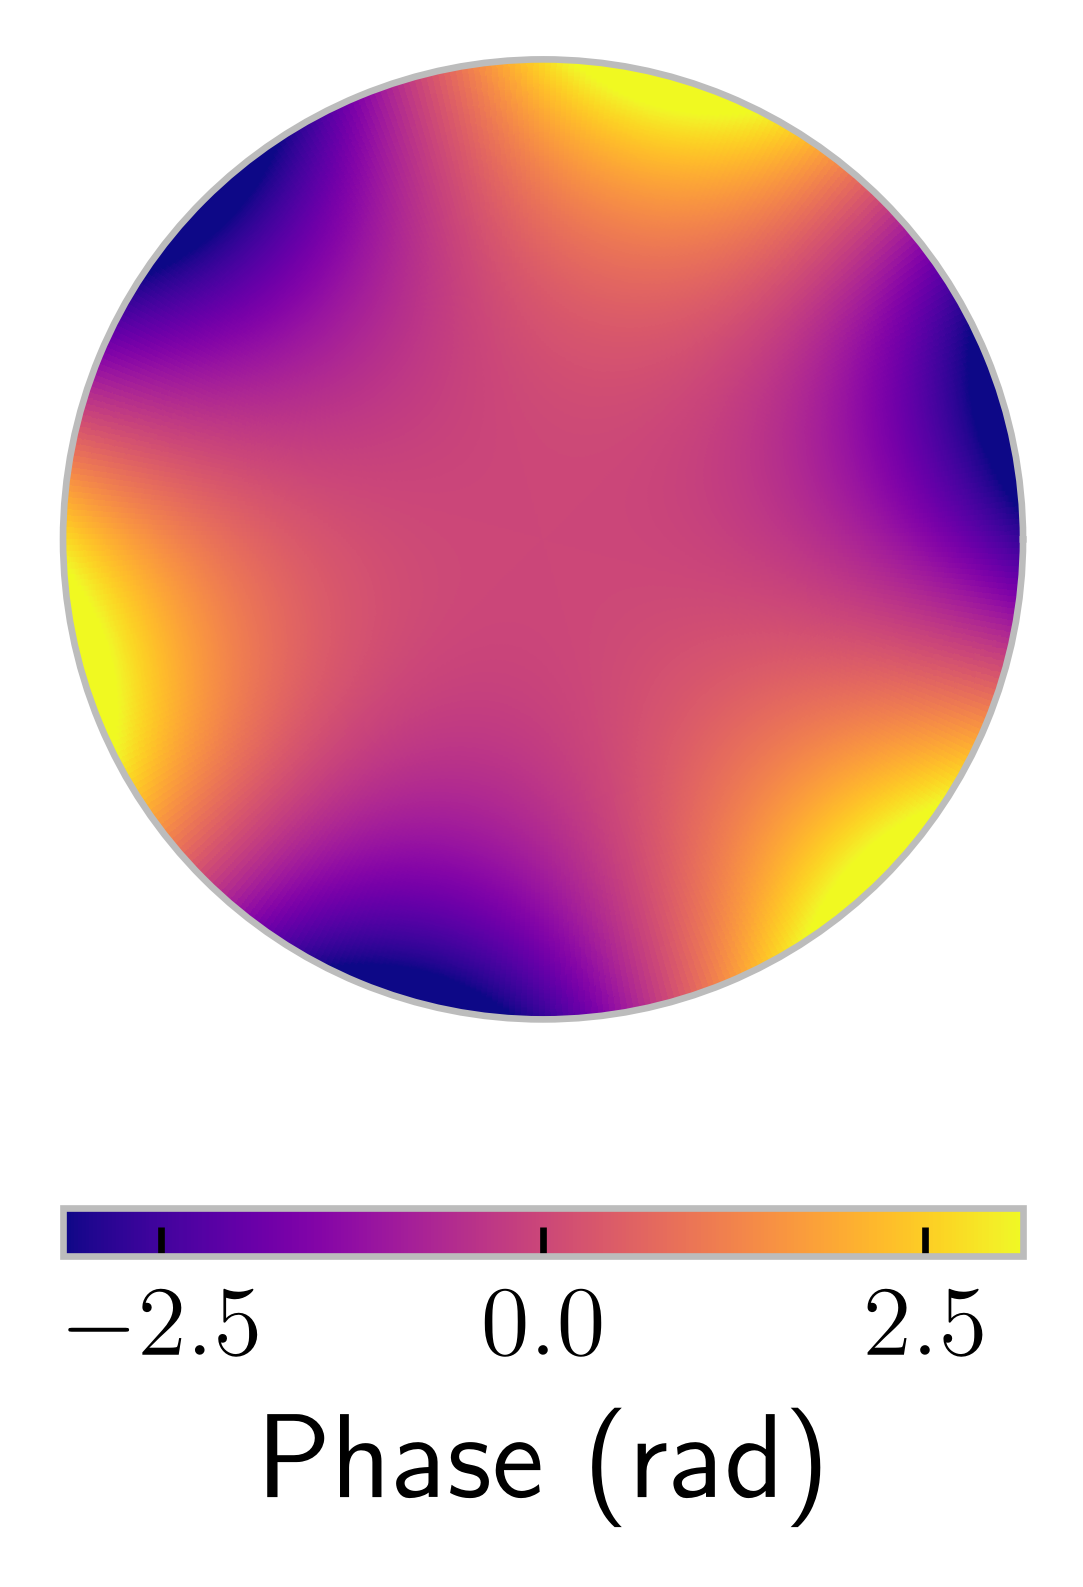

(<Figure size 1200x1800 with 2 Axes>, <PolarAxes: >)

In [5]:
plotting.zernike_plot(aberration.construct_map(microscope.alpha), microscope.alpha)

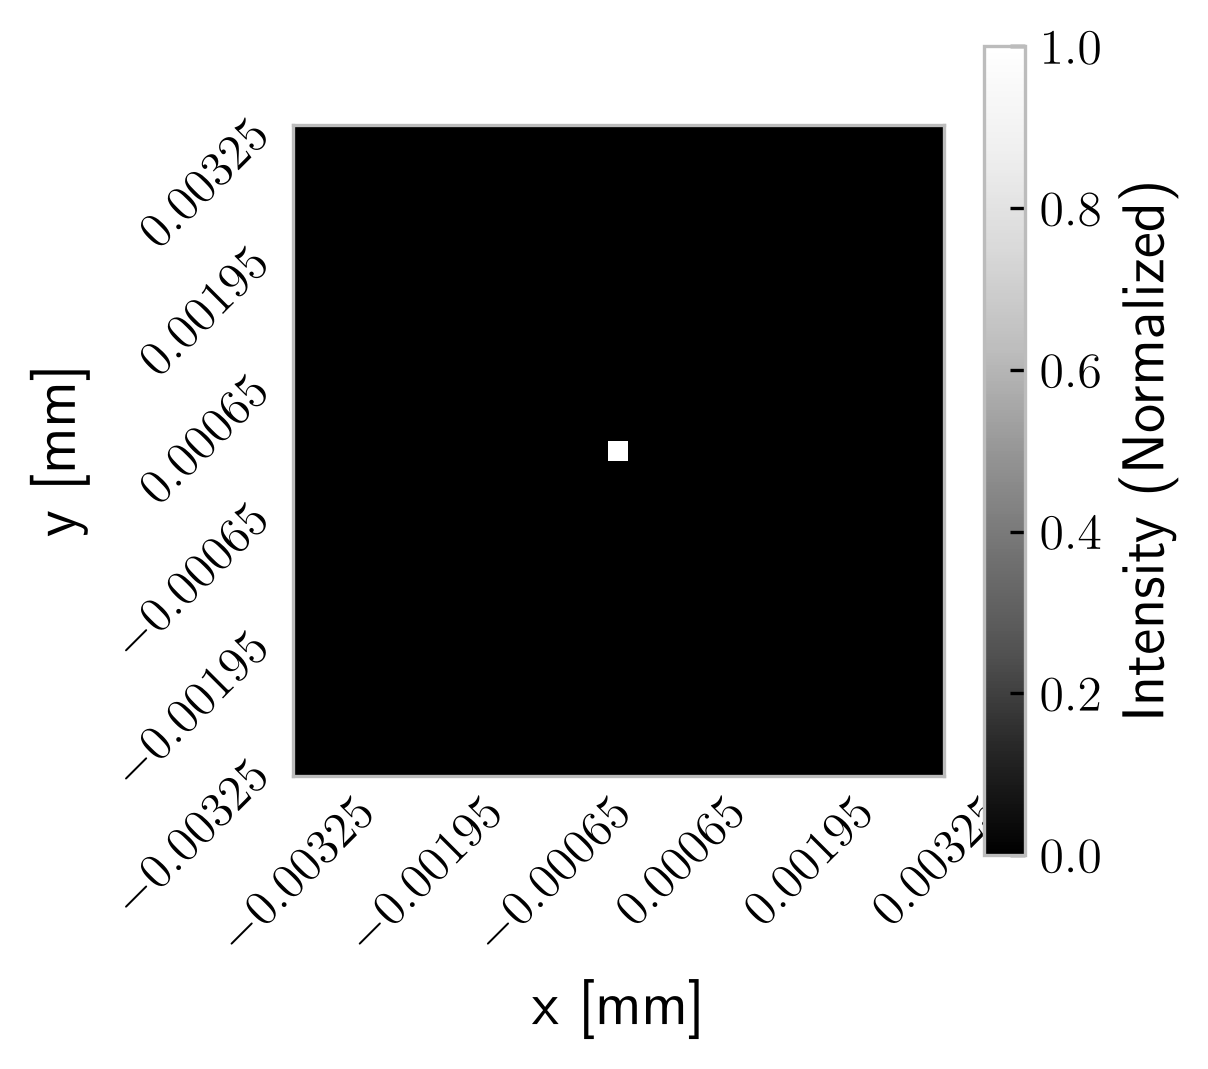

(<Figure size 1050x1050 with 2 Axes>, <Axes: xlabel='x [mm]', ylabel='y [mm]'>)

In [6]:
plotting.plot_intensity(xs, ys, mask.image_mask)

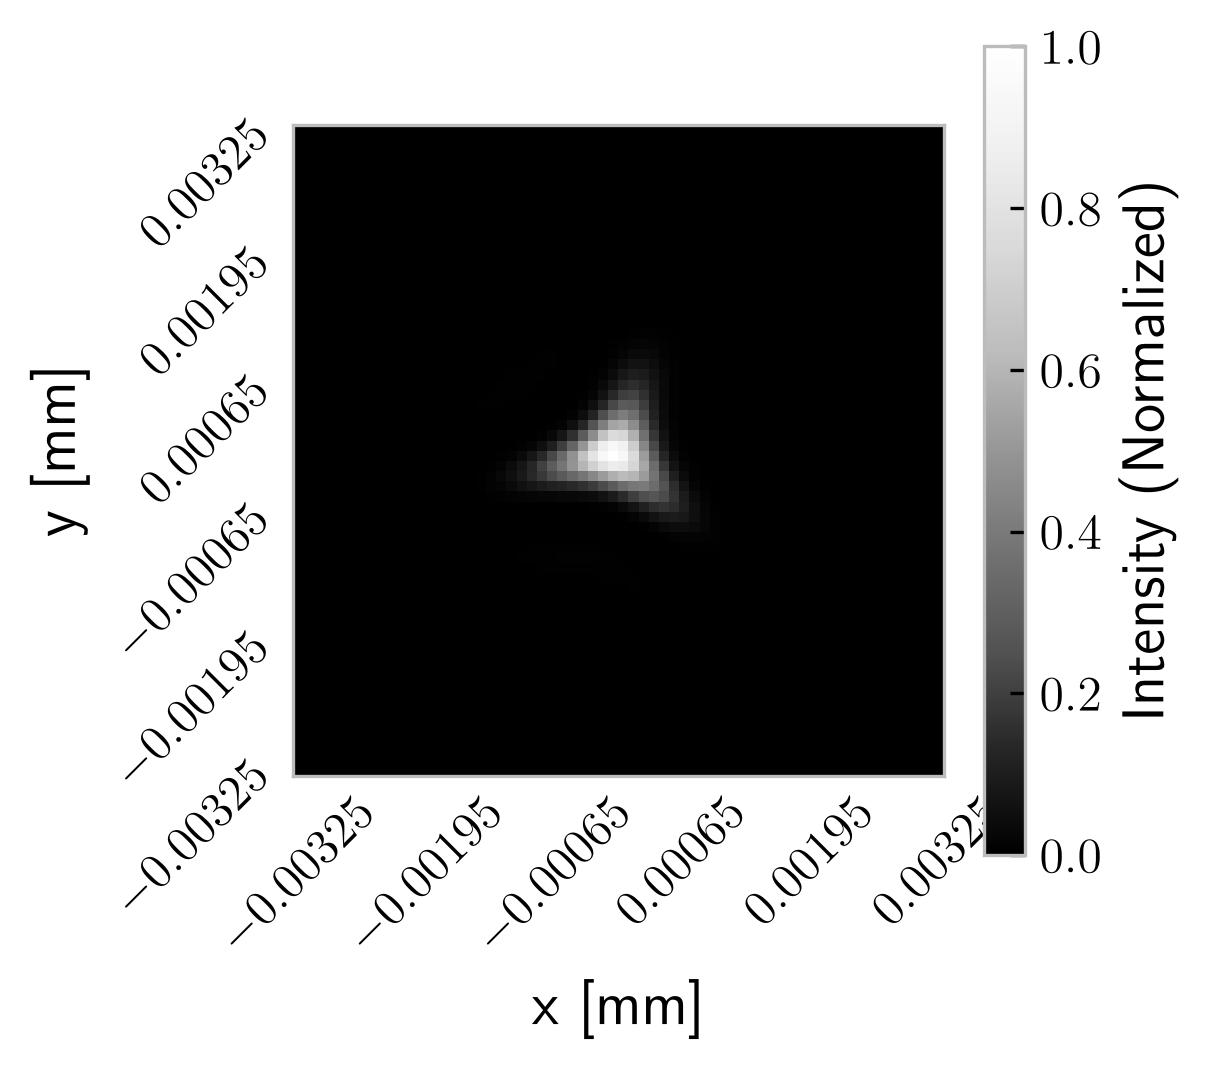

(<Figure size 1050x1050 with 2 Axes>, <Axes: xlabel='x [mm]', ylabel='y [mm]'>)

In [7]:
xs, ys, aberrated_img = microscope.compute_image(image = mask,
                         aberration = aberration,
                         mode = "vector",
                         norm = False)

plotting.plot_intensity(xs, ys, aberrated_img)

In [8]:
z_sample_levels = np.arange(-0.002, 0.002, 0.00010)

In [10]:
mask_3D = psf.bead_img_3D(grid = grid,
                          z_levels = z_sample_levels,
                          xs = [0],
                          ys = [0],
                          zs = [0],
                          bead_sizes = [0.001])

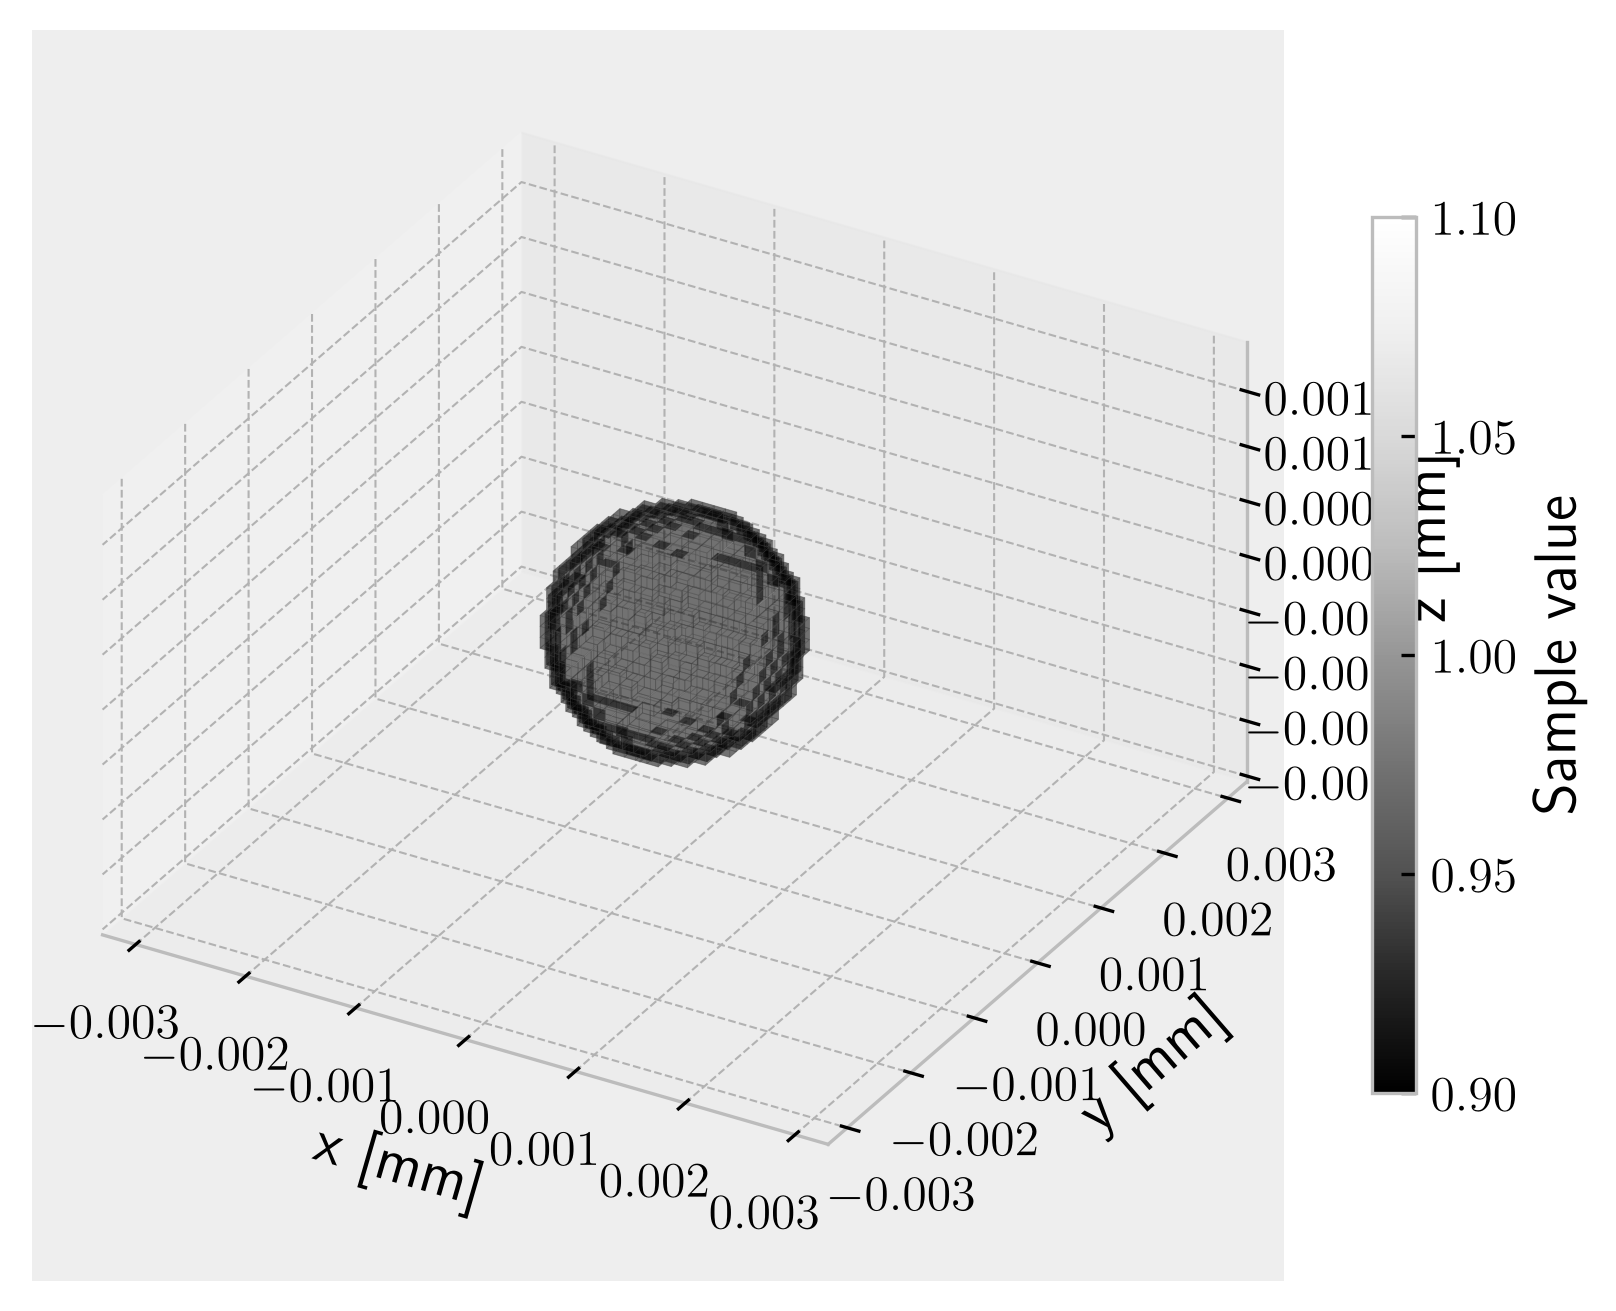

In [11]:
fig, ax = plotting.plot_sample_3D(mask_3D)

In [12]:
eps = 0.000001
z_image_levels = np.arange(-0.002, 0.002, 0.0005)

# Acquire every focal plane with three known spherical diversities (waves).
focal_positions = z_image_levels.copy()
diversity_strengths = [0.0, -0.05, 0.05]
z_image_levels = np.tile(focal_positions, len(diversity_strengths))
diversities = [
    zernike.Aberration([[0, 4]], [strength])
    for strength in diversity_strengths
    for _ in focal_positions
]


In [13]:
z_image_levels

array([-0.002 , -0.0015, -0.001 , -0.0005,  0.    ,  0.0005,  0.001 ,
        0.0015, -0.002 , -0.0015, -0.001 , -0.0005,  0.    ,  0.0005,
        0.001 ,  0.0015, -0.002 , -0.0015, -0.001 , -0.0005,  0.    ,
        0.0005,  0.001 ,  0.0015])

In [14]:
x, y, z, I = microscope.compute_image_3D(image = mask_3D,
                            aberration = aberration,
                            focal_z_levels = z_image_levels,
                            diversities = diversities)

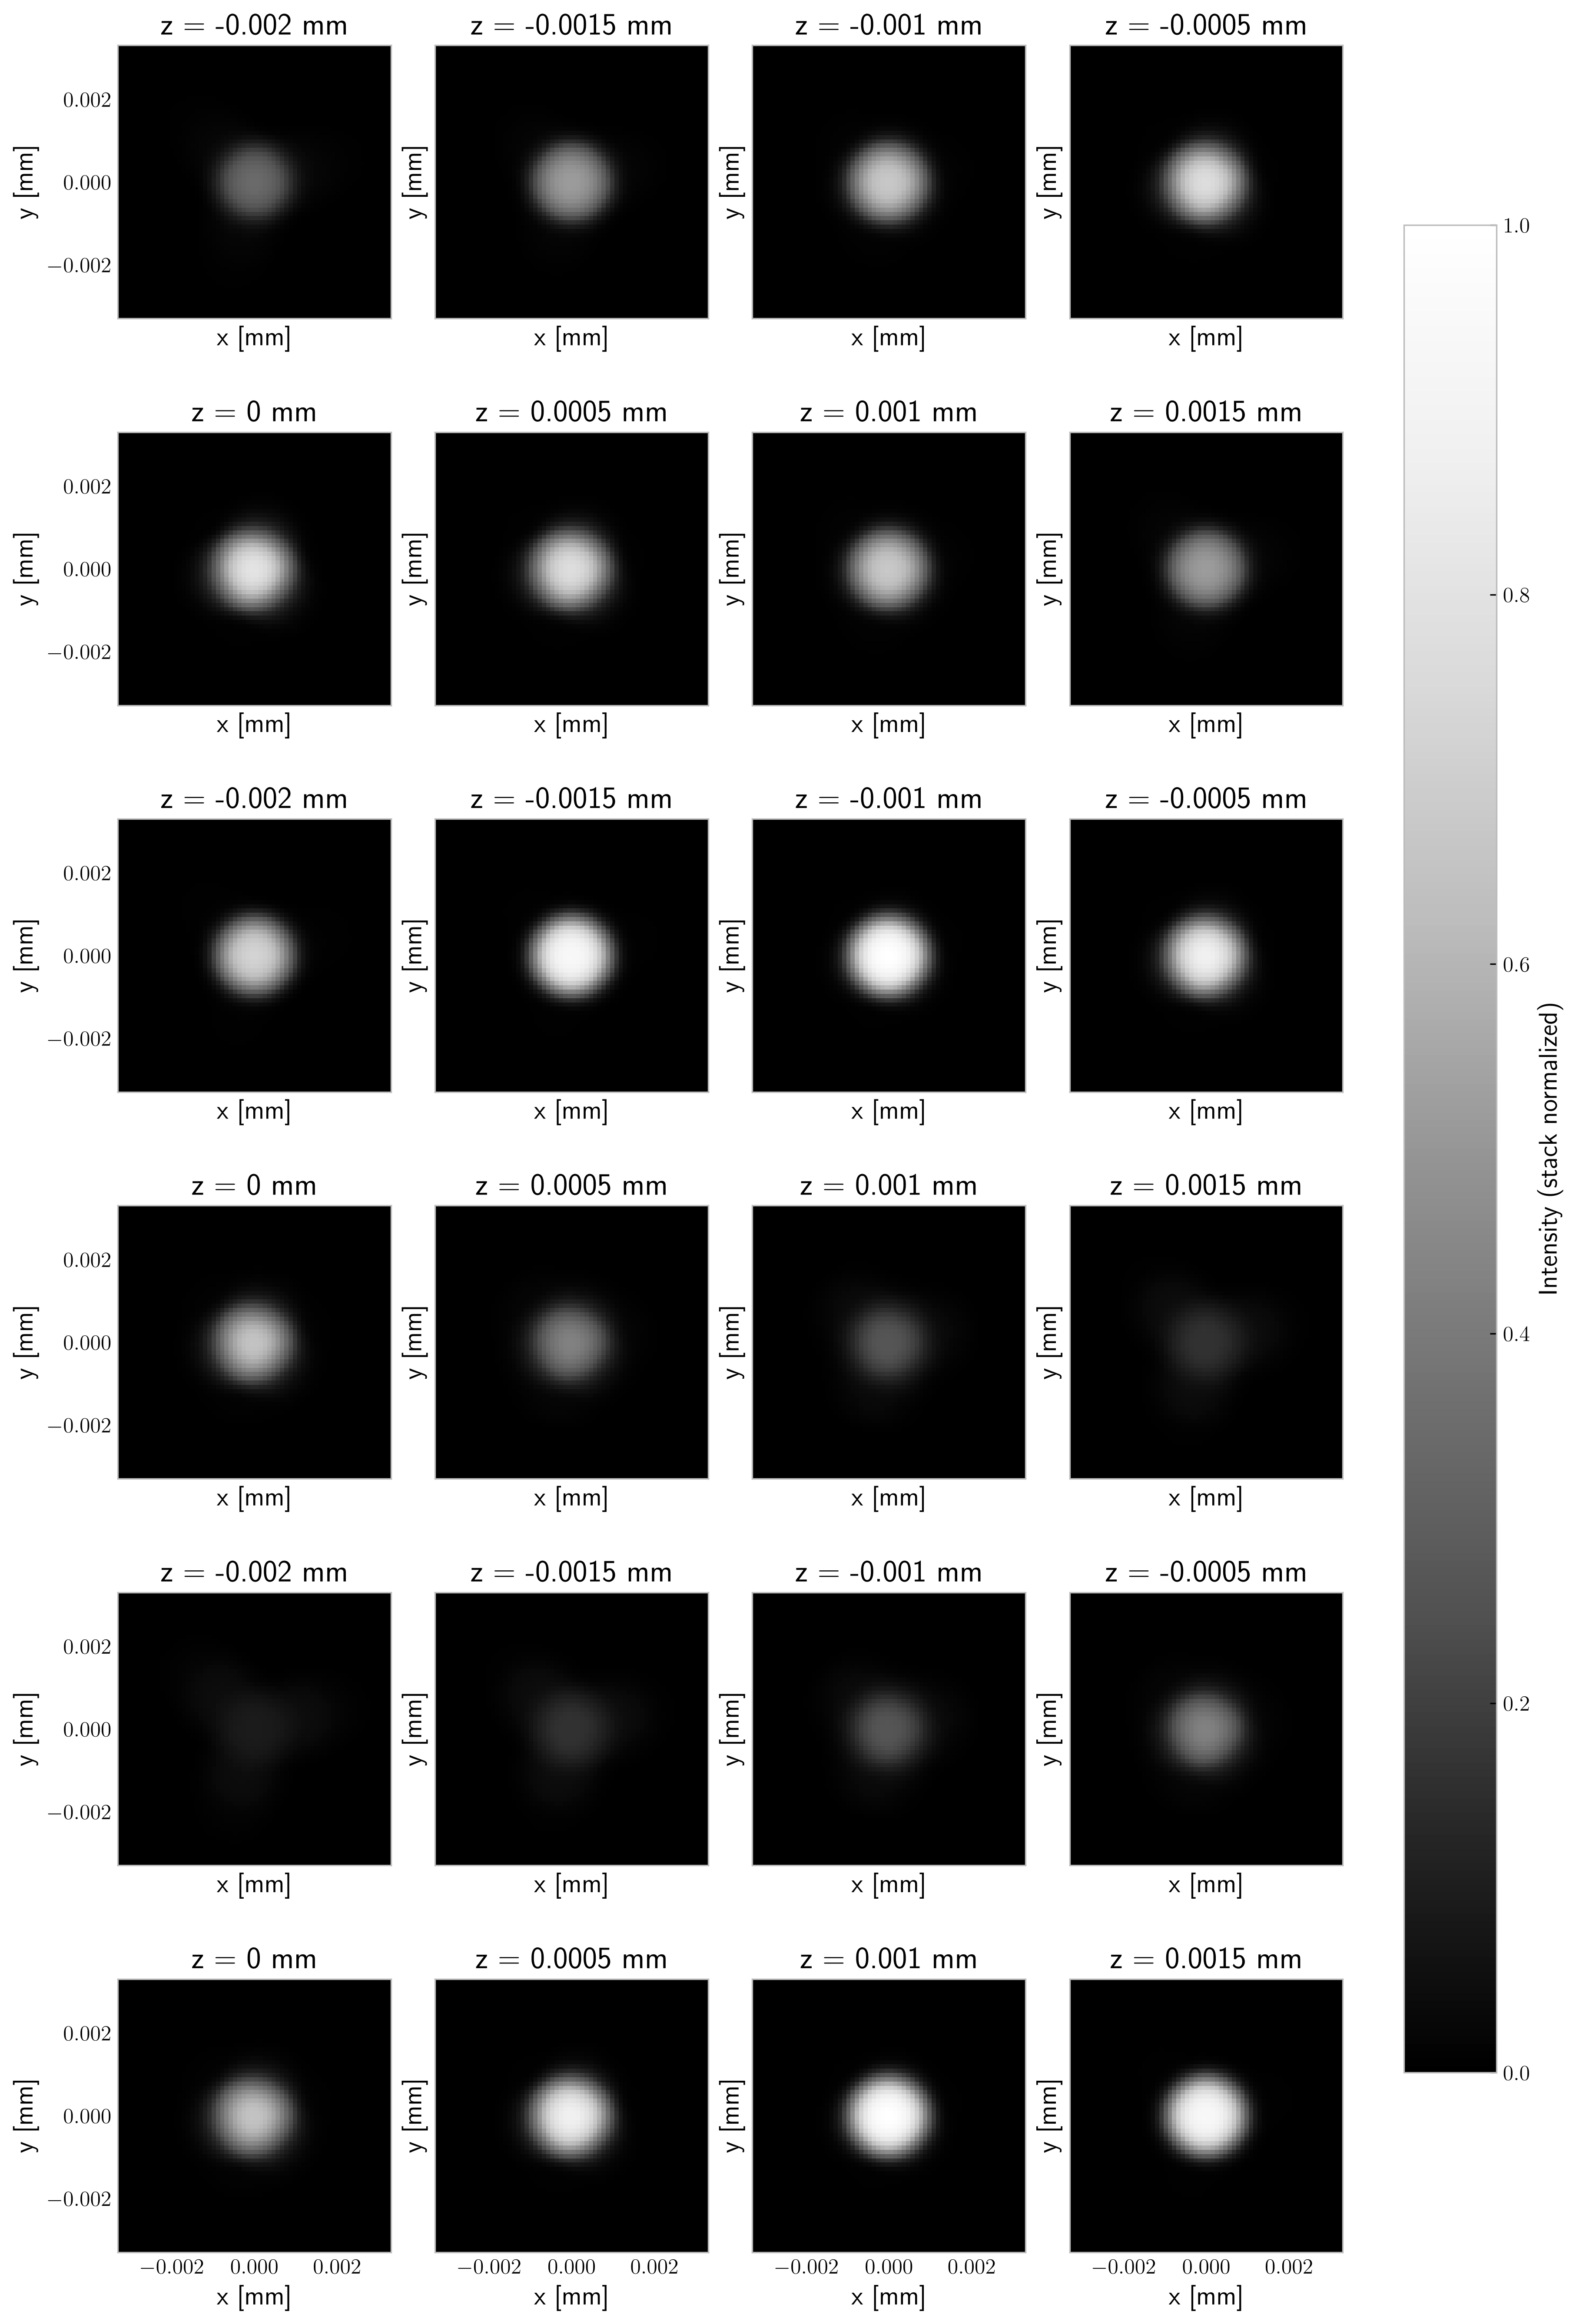

In [15]:
fig, axs = plotting.plot_image_stack(x, y, z, I, ncols=4)

In [16]:
from optimization import reconstruction

In [17]:
reconstructed_img = reconstruction.estimate_sample_3D(microscope = microscope,
                                  grid = grid,
                                  images = I,
                                  focal_z_levels = z_image_levels,
                                  diversities = diversities,
                                  sample_z_levels = z_sample_levels,
                                  aberration = aberration,
                                  rho = 1e48)

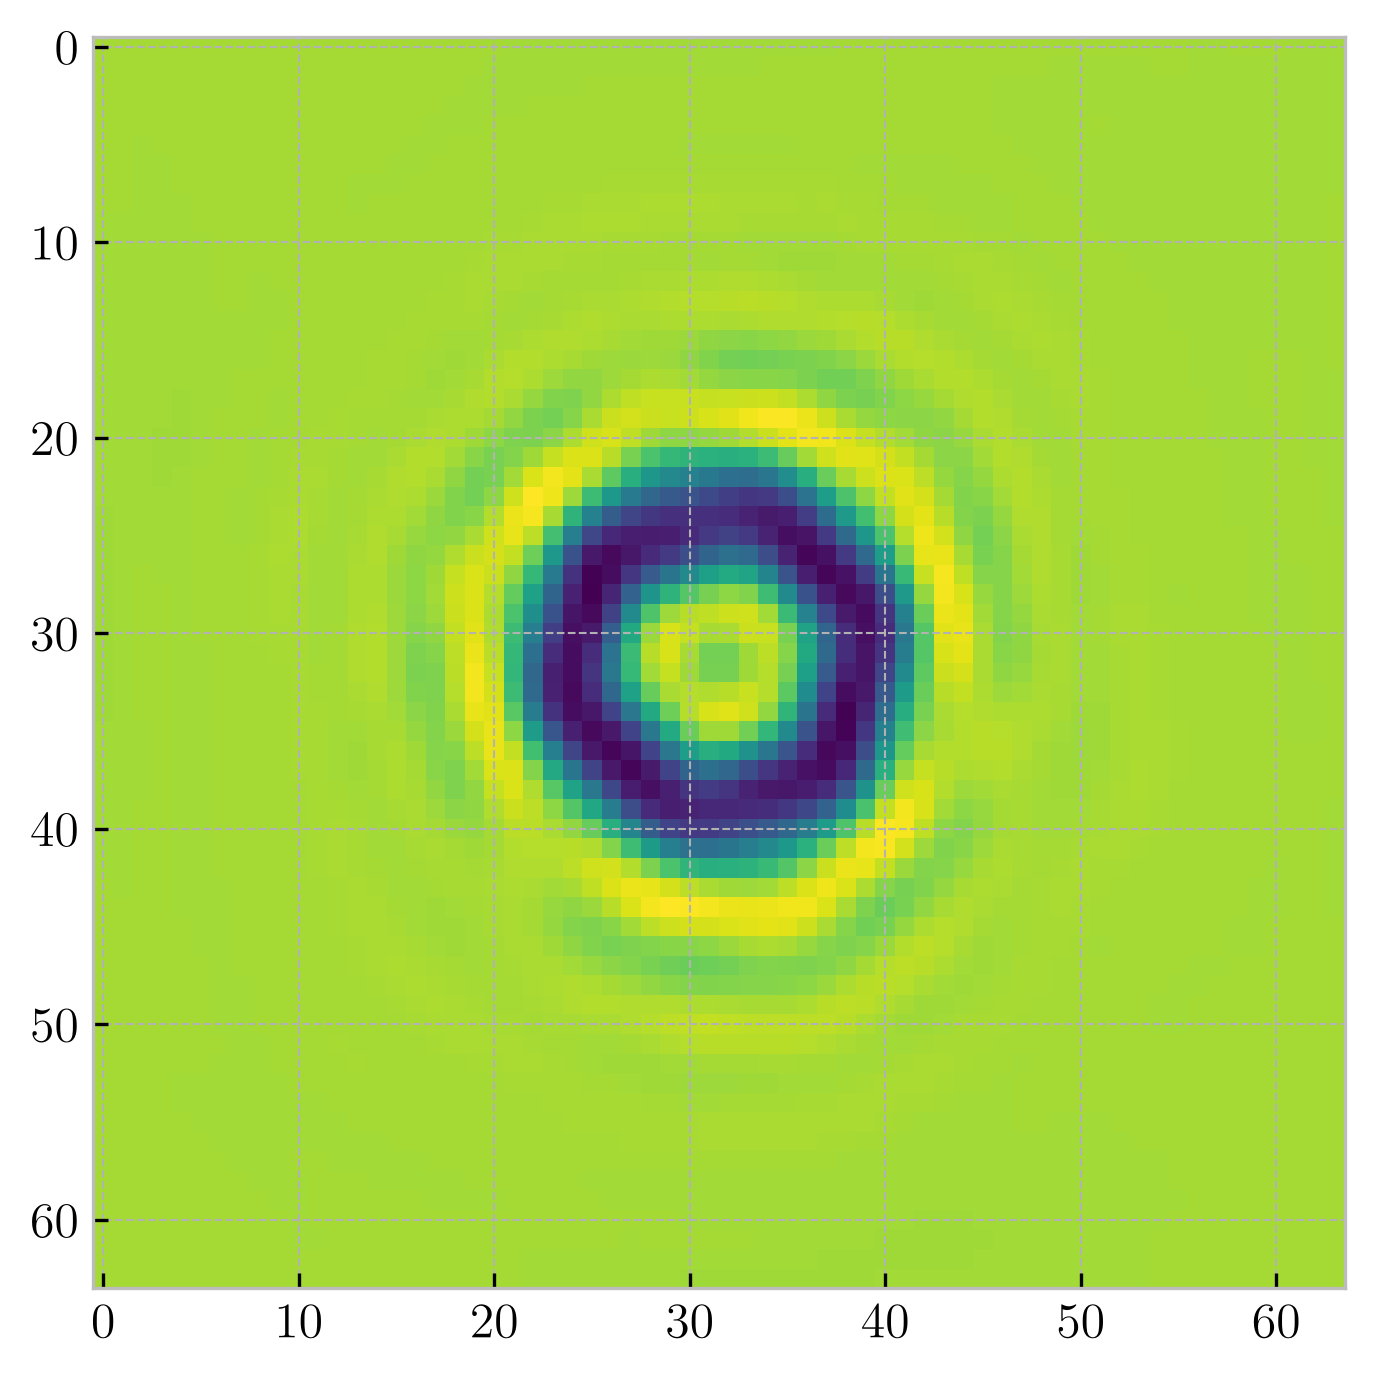

In [18]:
plt.imshow(reconstructed_img.image_mask[35])

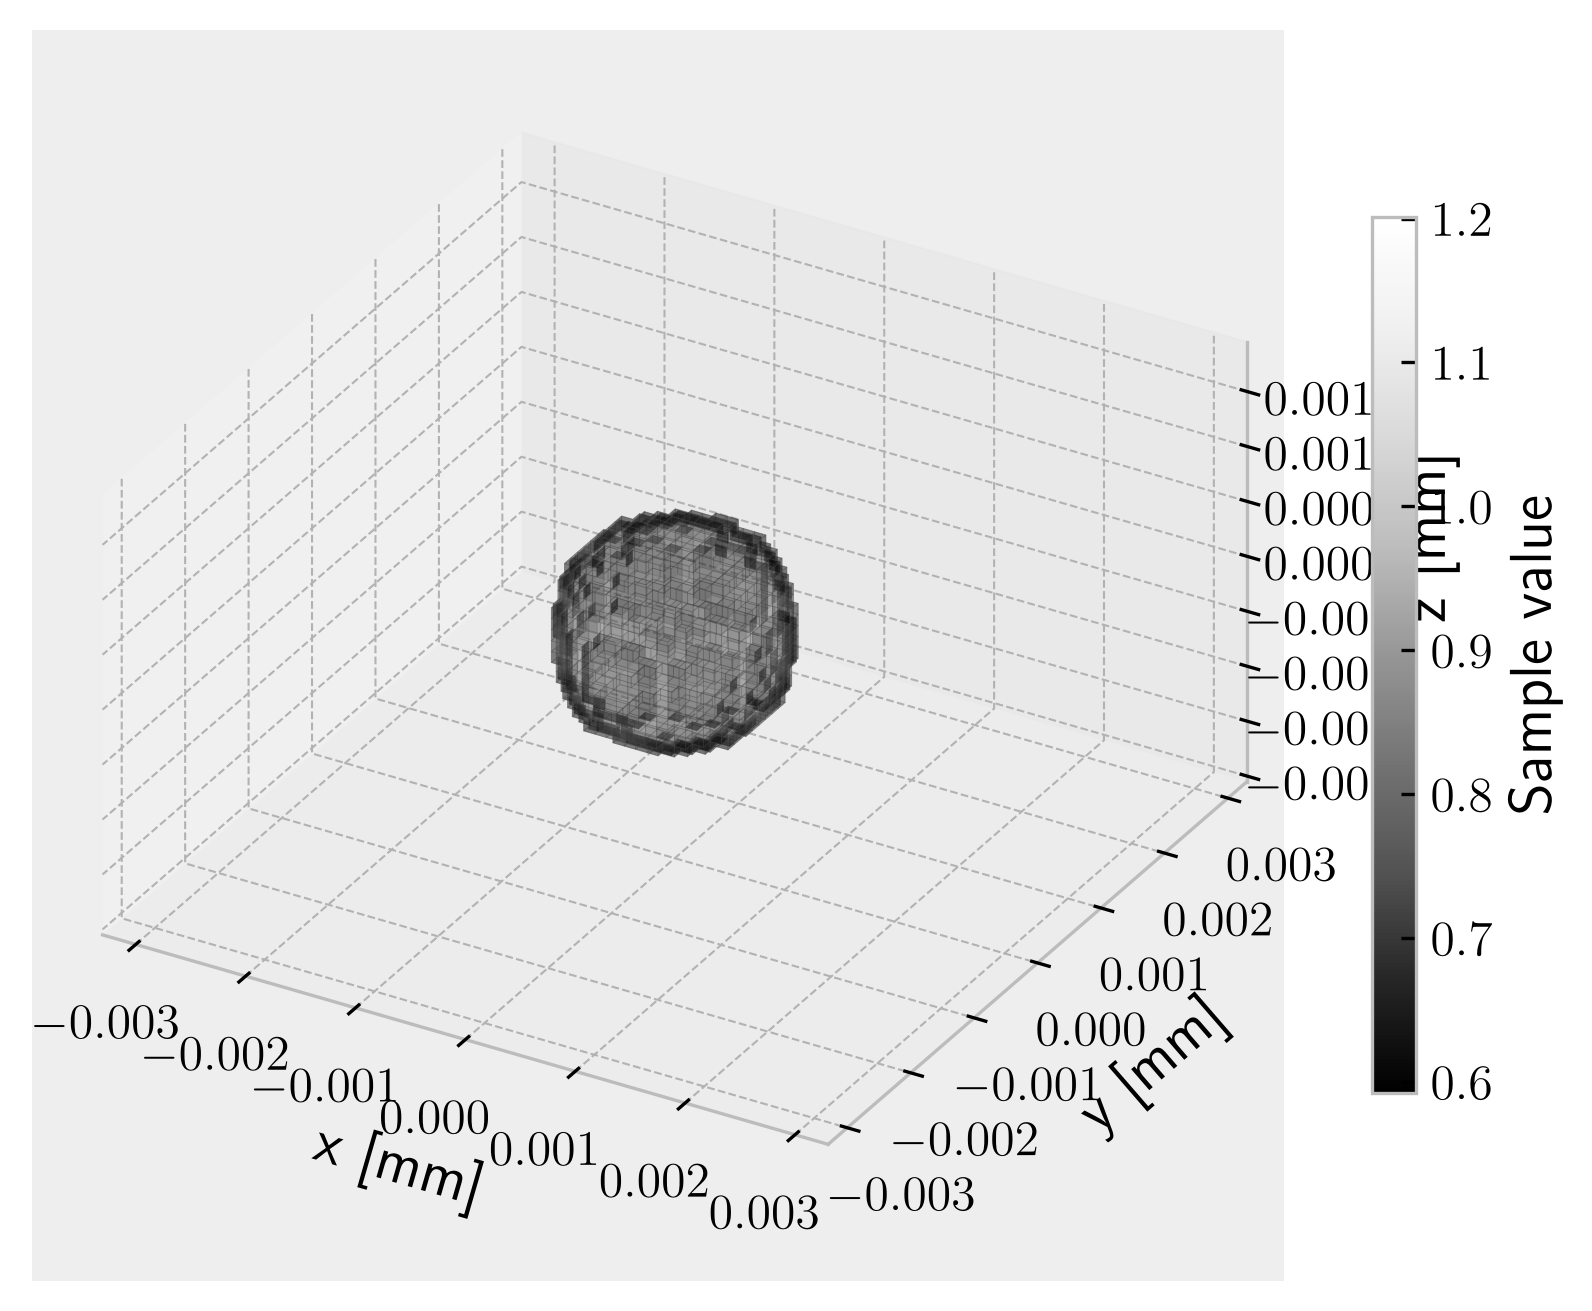

In [19]:
fig, ax = plotting.plot_sample_3D(reconstructed_img, np.percentile(reconstructed_img.image_mask,98))

array([[-0.2 , -0.19, -0.18, ...,  0.17,  0.18,  0.19],
       [-0.2 , -0.19, -0.18, ...,  0.17,  0.18,  0.19],
       [-0.2 , -0.19, -0.18, ...,  0.17,  0.18,  0.19],
       ...,
       [-0.2 , -0.19, -0.18, ...,  0.17,  0.18,  0.19],
       [-0.2 , -0.19, -0.18, ...,  0.17,  0.18,  0.19],
       [-0.2 , -0.19, -0.18, ...,  0.17,  0.18,  0.19]], shape=(40, 40))

In [ ]:
strengths = np.arange(-0.20, 0.20, 0.05)
losses = np.zeros((len(strengths), len(strengths)))
for i, strength_i in enumerate(strengths):
    for j, strength_j in enumerate(strengths):
        losses[i,j] = reconstruction.evaluate_loss_3D(microscope = microscope, 
                                        grid = grid,
                                        images = I,
                                        focal_z_levels = z_image_levels,
                                        diversities = diversities,
                                        sample_z_levels = z_sample_levels,
                                        aberration = zernike.Aberration([[-3,3], [3,3]], [strength_i, strength_j]),
                                        rho = 1e48)
        print(f"{strength_i, strength_j}, {losses[i, j]}")


(np.float64(-0.2), np.float64(-0.2)), 9.189417649292438e+56
(np.float64(-0.2), np.float64(-0.15000000000000002)), 4.761604692963504e+56
(np.float64(-0.2), np.float64(-0.10000000000000003)), 1.3490815610420525e+56
(np.float64(-0.2), np.float64(-0.050000000000000044)), 9.722038256022513e+55
(np.float64(-0.2), np.float64(-5.551115123125783e-17)), 2.5579880946455806e+56
(np.float64(-0.2), np.float64(0.04999999999999993)), 1.166533426170787e+56
(np.float64(-0.2), np.float64(0.09999999999999992)), 1.6582618152560871e+56
(np.float64(-0.2), np.float64(0.1499999999999999)), 5.145115621829288e+56
(np.float64(-0.15000000000000002), np.float64(-0.2)), 4.796615956513751e+56
(np.float64(-0.15000000000000002), np.float64(-0.15000000000000002)), 5.438331609563444e+55
(np.float64(-0.15000000000000002), np.float64(-0.10000000000000003)), 2.1149366388726256e+57
(np.float64(-0.15000000000000002), np.float64(-0.050000000000000044)), 4.801973045976936e+57
(np.float64(-0.15000000000000002), np.float64(-5.551

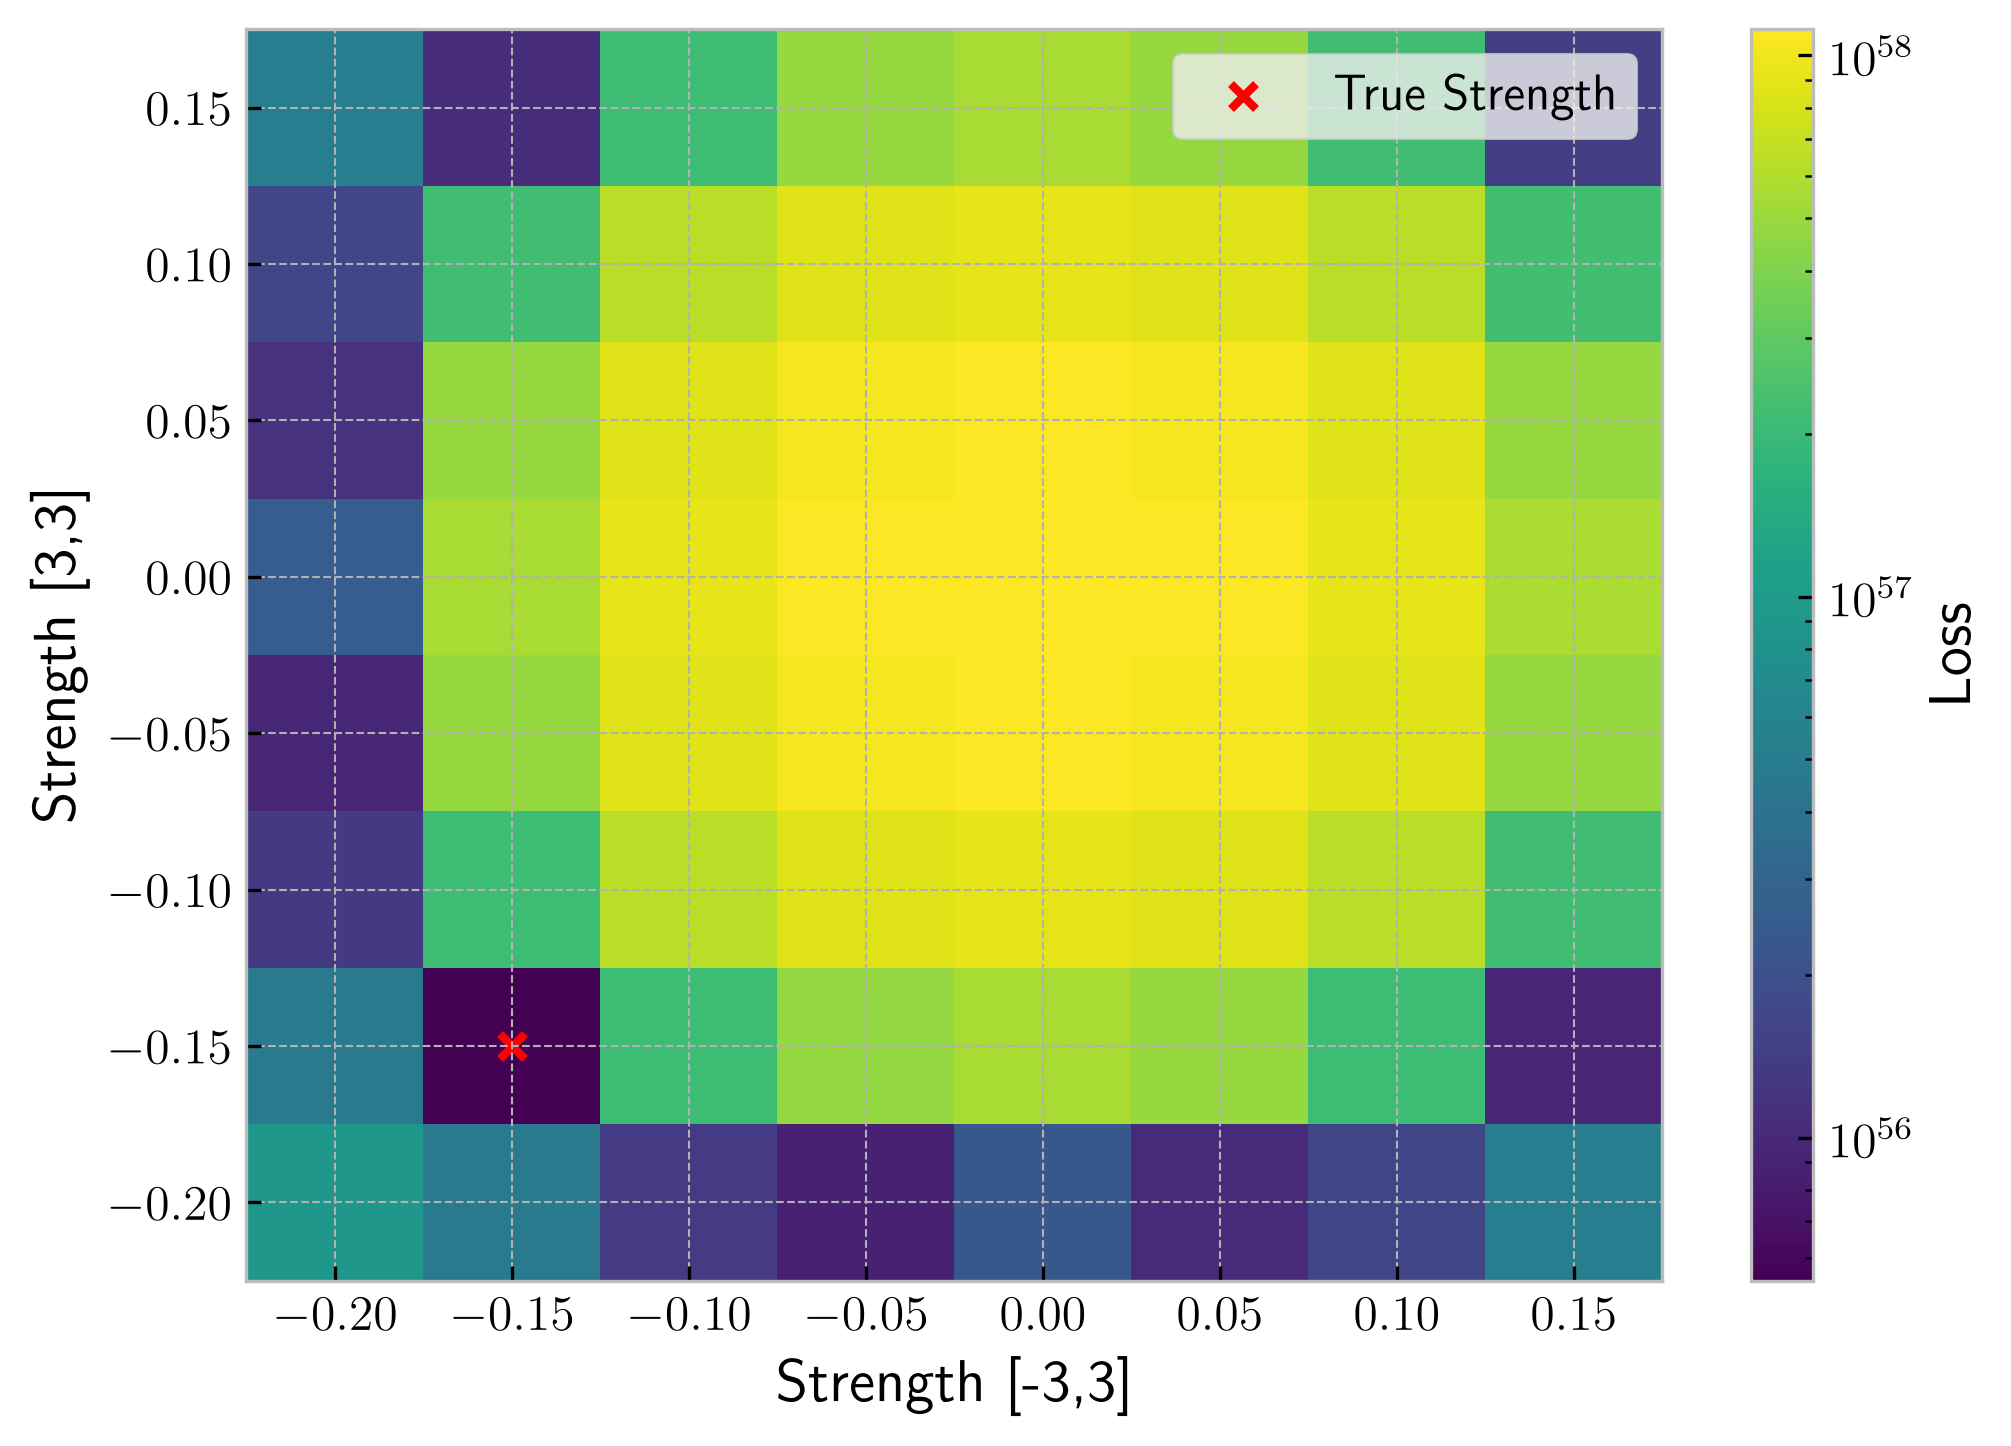

In [53]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots()
grid_i, grid_j = np.meshgrid(strengths, strengths, indexing="ij")

mesh = ax.pcolormesh(
    grid_i, grid_j, losses,
    cmap="viridis",
    norm=LogNorm(vmin=losses.min(), vmax=losses.max()),
    shading="nearest",
)

fig.colorbar(mesh, ax=ax, label="Loss")
ax.set(xlabel="Strength [-3,3]", ylabel="Strength [3,3]")
ax.scatter(-0.15, -0.15, marker = "x", color = "red", label = "True Strength")
ax.legend()
plt.show()

In [54]:
estimated, info = reconstruction.optimize_aberration_3D(
    microscope=microscope,
    grid=grid,
    images=I,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    modes=[[-3,3], [3,3]],
    rho=1e48,
    diversities=diversities,
    initial_strengths=[0.0, 0.0],
)

Iteration 0: loss=1.1171513853e+58, strengths (waves)=[0. 0.]
Iteration 1: loss=9.2148364705e+57, strengths (waves)=[-0.1        0.0050932]
Iteration 2: loss=2.4880122978e+56, strengths (waves)=[-0.2         0.01008165]
Iteration 3: loss=1.3766676728e+56, strengths (waves)=[-0.20487576 -0.08991835]
Iteration 4: loss=6.0275722119e+55, strengths (waves)=[-0.19224328 -0.0854291 ]
Iteration 5: loss=5.5732356922e+55, strengths (waves)=[-0.18126286 -0.1104291 ]
Iteration 6: loss=5.5595604312e+55, strengths (waves)=[-0.17155881 -0.12642739]
Iteration 7: loss=5.4849166423e+55, strengths (waves)=[-0.16838296 -0.12923664]
Iteration 8: loss=5.4666286933e+55, strengths (waves)=[-0.16334946 -0.1358069 ]
Iteration 9: loss=5.4515860642e+55, strengths (waves)=[-0.15694017 -0.14325527]
Iteration 10: loss=5.4412702761e+55, strengths (waves)=[-0.15333591 -0.14684801]
Iteration 11: loss=5.4374620956e+55, strengths (waves)=[-0.14791373 -0.15240326]
Iteration 12: loss=5.4349938166e+55, strengths (waves)=[-0

In [59]:
modes = [[-2,2],
         [2,2],
         [-3,3],
         [3,3],
         [0,4]]

underlying_strength = -0.05
underlying_strengths = [underlying_strength] *5

aberration = zernike.Aberration(modes = modes,
                                strengths = underlying_strengths)


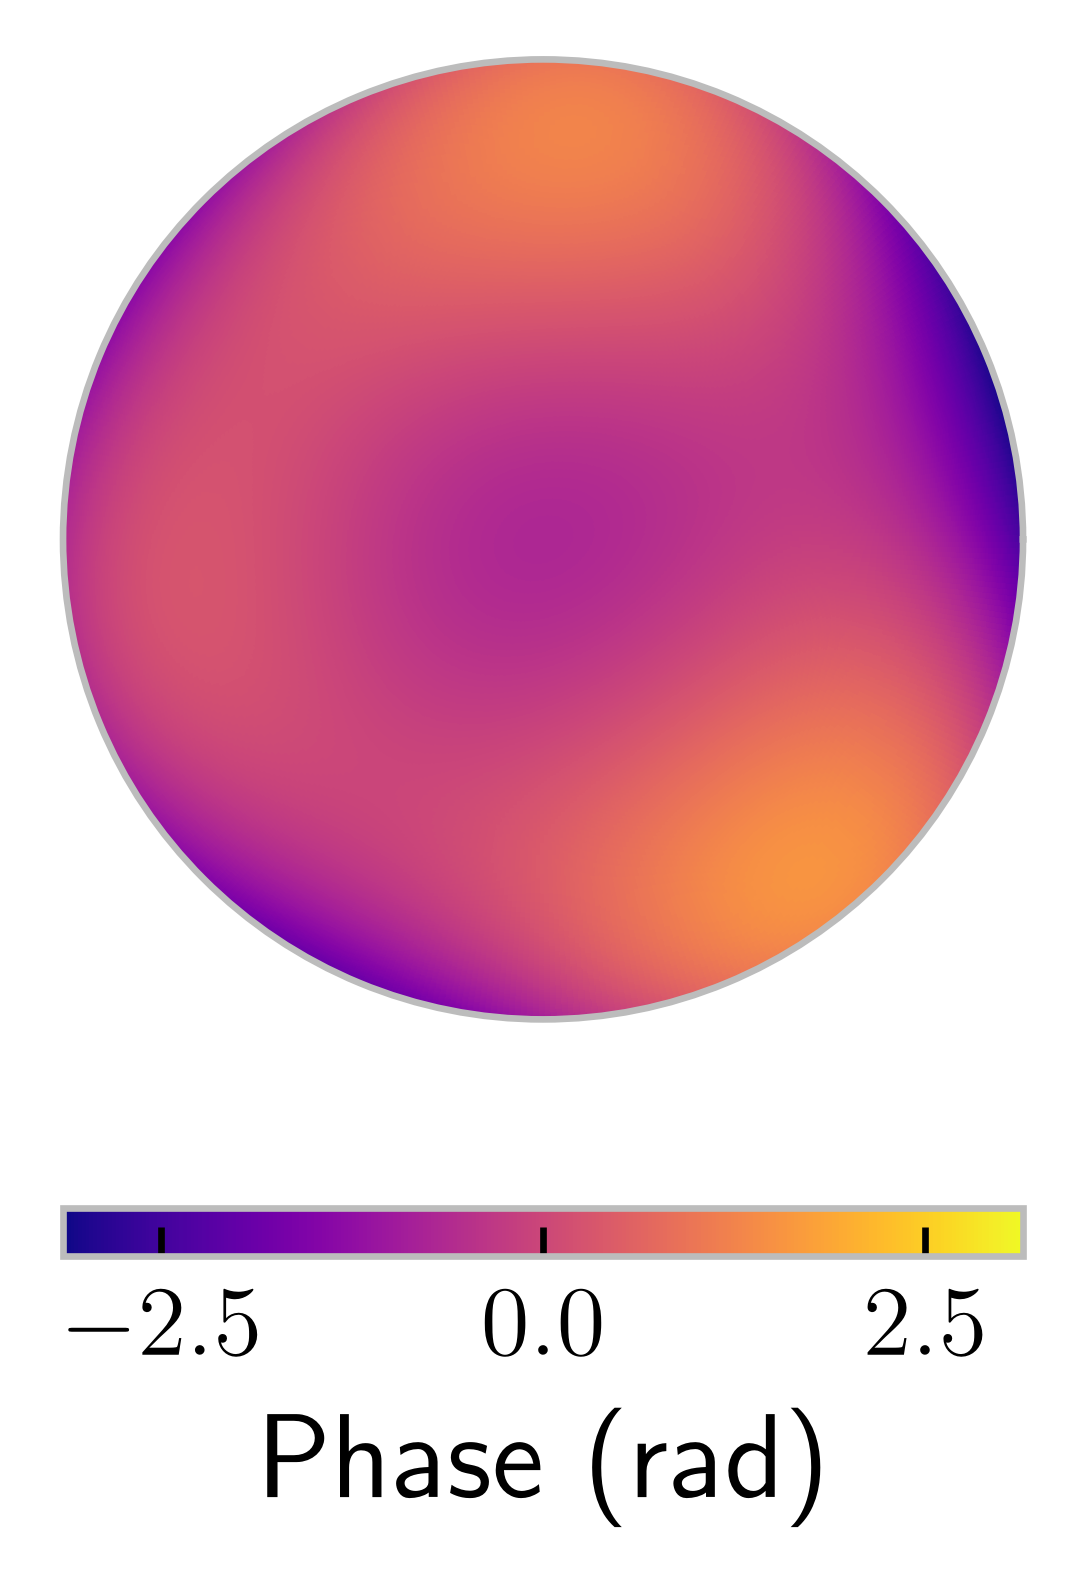

(<Figure size 1200x1800 with 2 Axes>, <PolarAxes: >)

In [60]:
plotting.zernike_plot(aberration.construct_map(microscope.alpha), microscope.alpha)

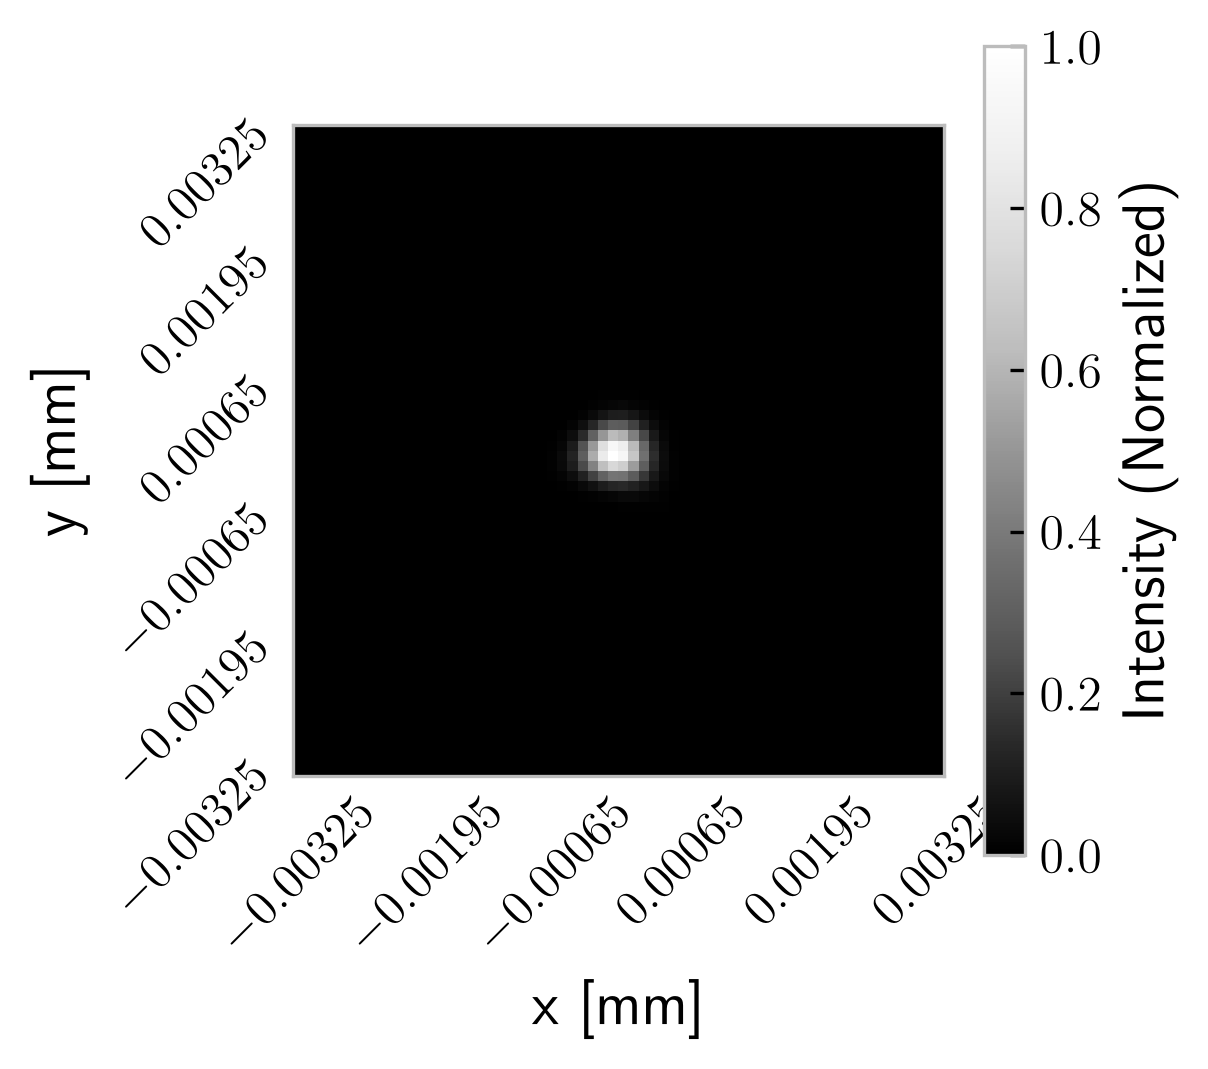

(<Figure size 1050x1050 with 2 Axes>, <Axes: xlabel='x [mm]', ylabel='y [mm]'>)

In [61]:
xs, ys, aberrated_img = microscope.compute_image(image = mask,
                         aberration = aberration,
                         mode = "vector",
                         norm = False)

plotting.plot_intensity(xs, ys, aberrated_img)

In [62]:
eps = 0.000001
z_image_levels = np.arange(-0.002, 0.002, 0.0005)

# Acquire every focal plane with three known spherical diversities (waves).
focal_positions = z_image_levels.copy()
diversity_strengths = [0.0, -0.05, 0.05]
z_image_levels = np.tile(focal_positions, len(diversity_strengths))
diversities = [
    zernike.Aberration([[0, 4]], [strength])
    for strength in diversity_strengths
    for _ in focal_positions
]


In [63]:
x, y, z, I = microscope.compute_image_3D(image = mask_3D,
                            aberration = aberration,
                            focal_z_levels = z_image_levels,
                            diversities = diversities)

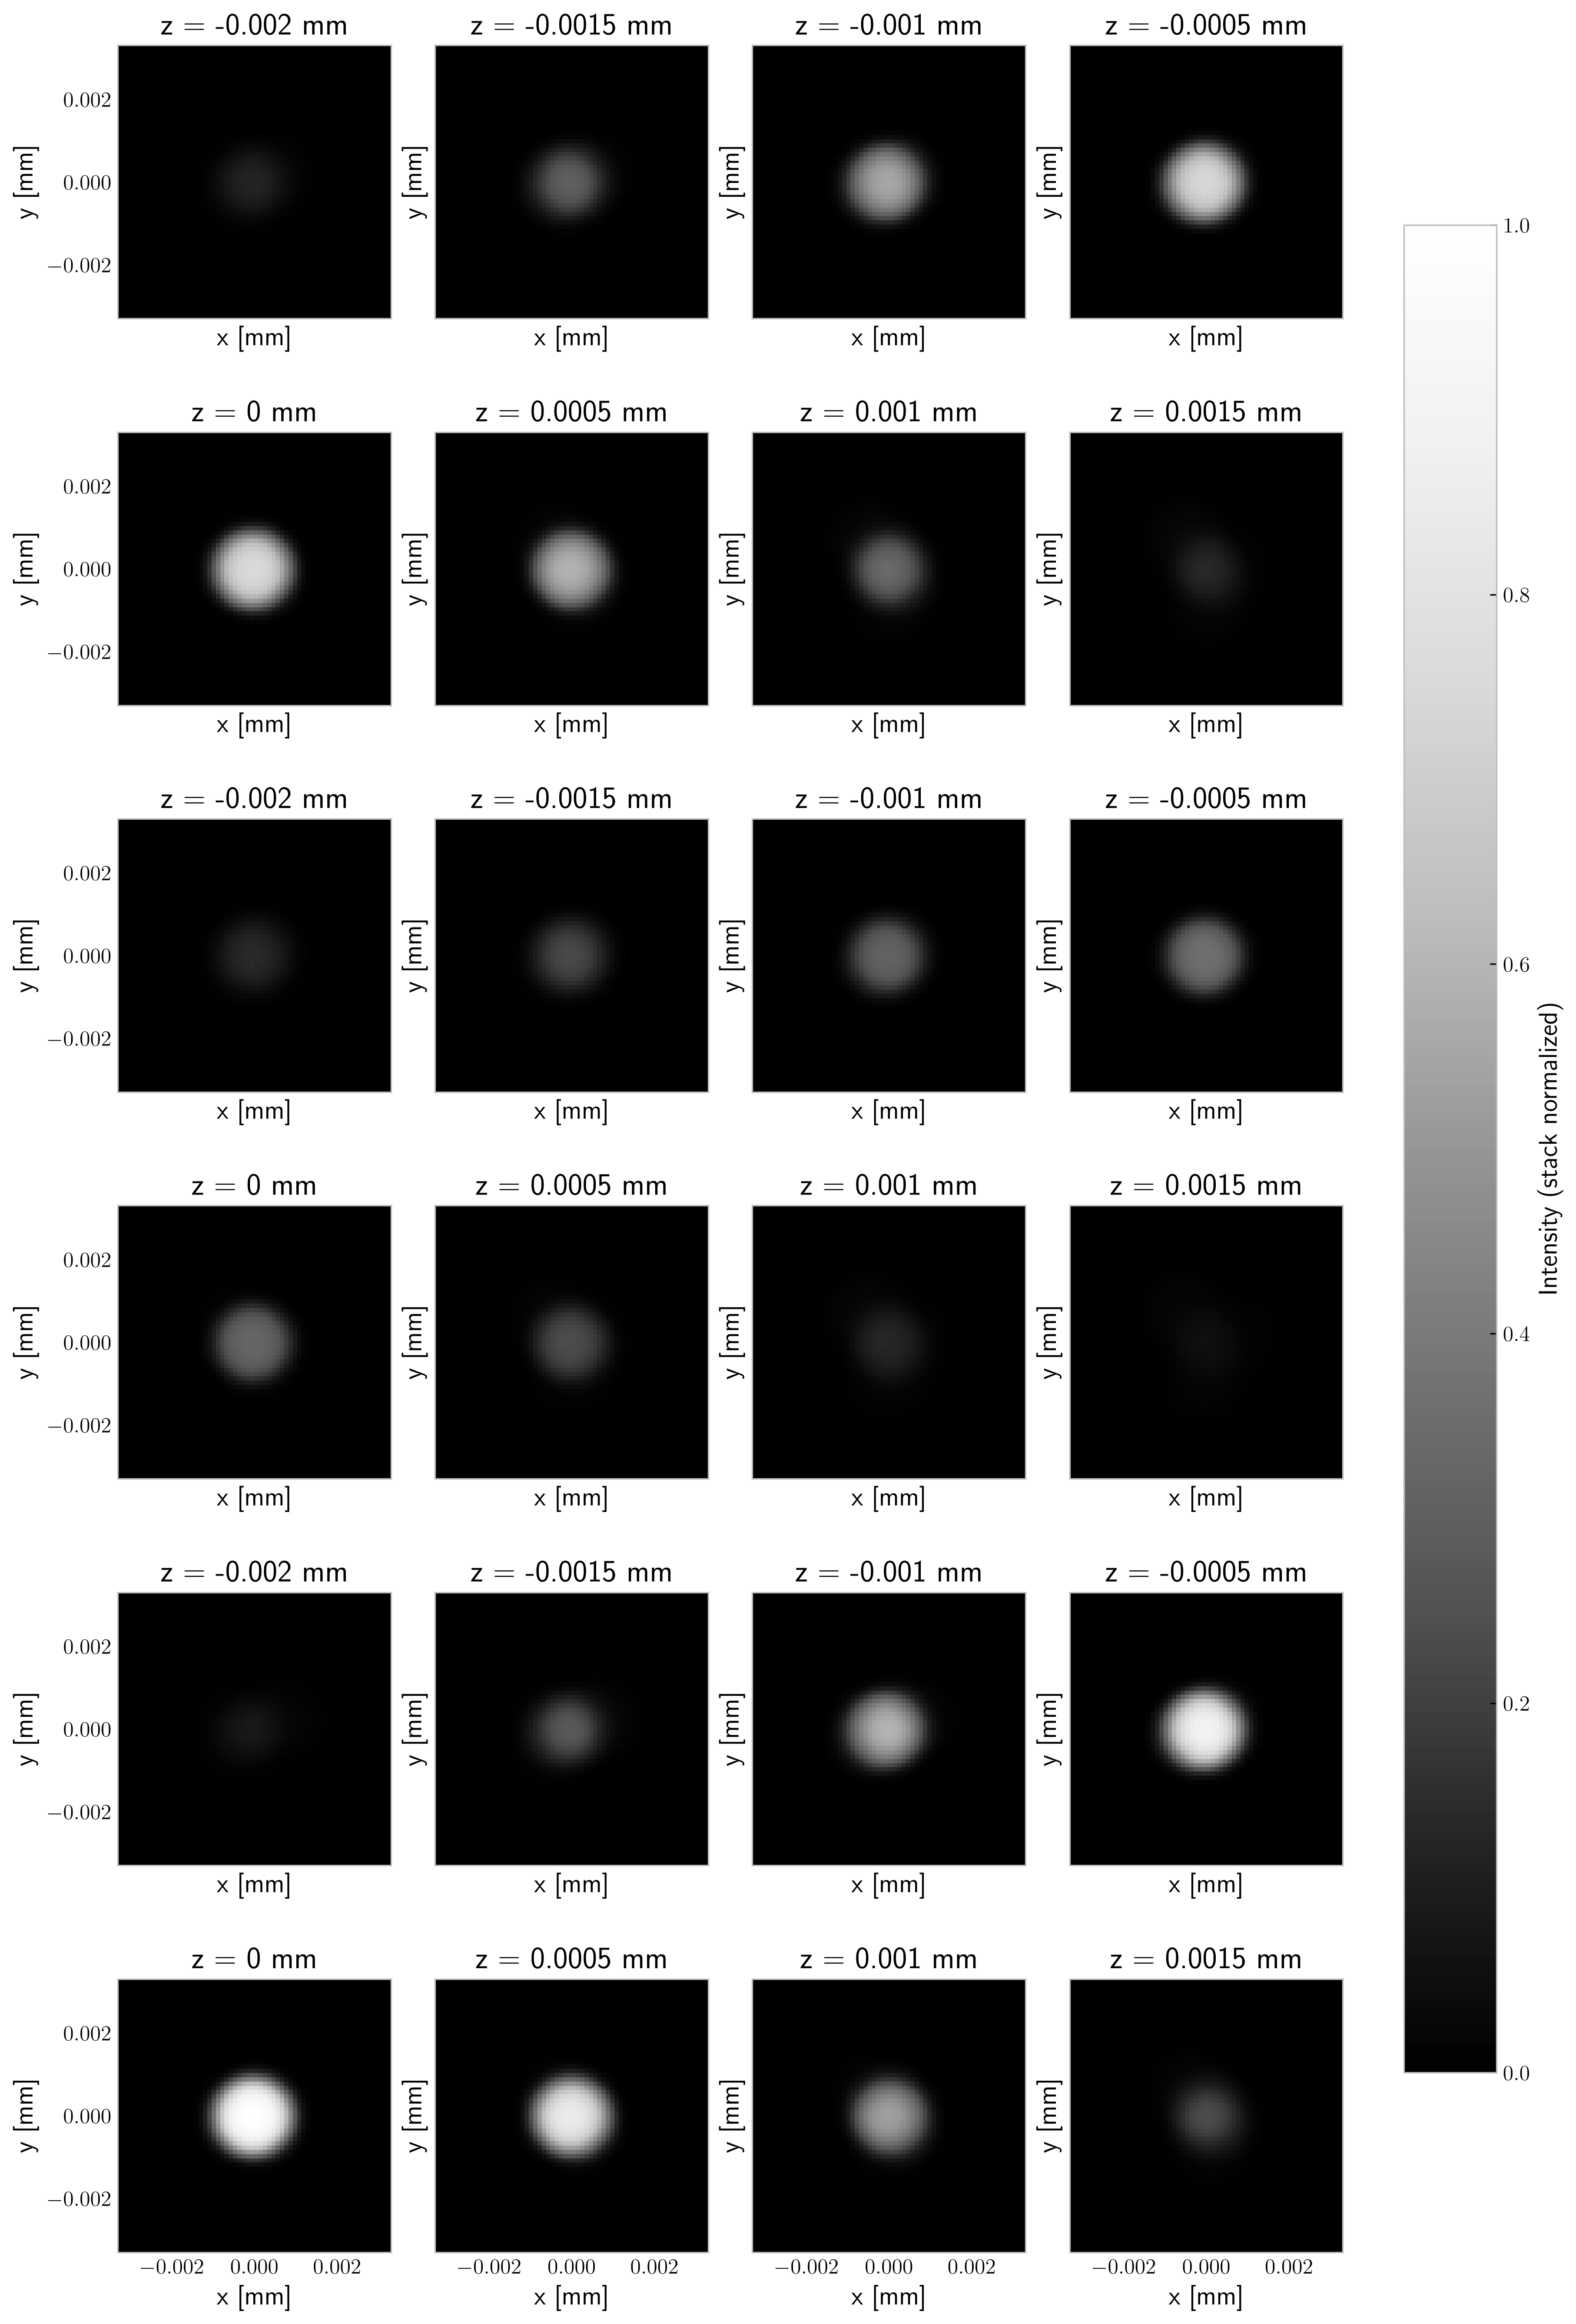

In [64]:
fig, axs = plotting.plot_image_stack(x, y, z, I, ncols=4)

In [65]:
estimated, info = reconstruction.optimize_aberration_3D(
    microscope=microscope,
    grid=grid,
    images=I,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    modes= modes,
    rho=1e48,
    diversities=diversities,
    initial_strengths=[0.0] * len(modes),
)

Iteration 0: loss=2.7390602140e+59, strengths (waves)=[0. 0. 0. 0. 0.]
Iteration 1: loss=2.5873049351e+59, strengths (waves)=[ 0.00096301  0.1        -0.01397474 -0.00065751  0.00076582]
Iteration 2: loss=1.5994516560e+59, strengths (waves)=[-0.00216202  0.          0.00411116  0.01054516 -0.01102795]
Iteration 3: loss=1.5650896959e+59, strengths (waves)=[ 0.00577378  0.03090132 -0.03546919 -0.08945484 -0.01146665]
Iteration 4: loss=1.5572204479e+59, strengths (waves)=[ 0.03077378  0.01454224 -0.02163824 -0.09544808 -0.01180278]
Iteration 5: loss=1.2796707857e+59, strengths (waves)=[ 0.13077378  0.08534887 -0.00863869 -0.07783562 -0.01314086]
Iteration 6: loss=4.3386586324e+57, strengths (waves)=[ 0.03077378  0.03452257 -0.04158376 -0.00557282 -0.04325777]
Iteration 7: loss=3.1981067983e+57, strengths (waves)=[ 0.00577378  0.03060992 -0.06484103  0.00655695 -0.04350998]
Iteration 8: loss=3.0824528934e+57, strengths (waves)=[-0.04422622  0.0556633  -0.0616433   0.01110772 -0.04312031]
I

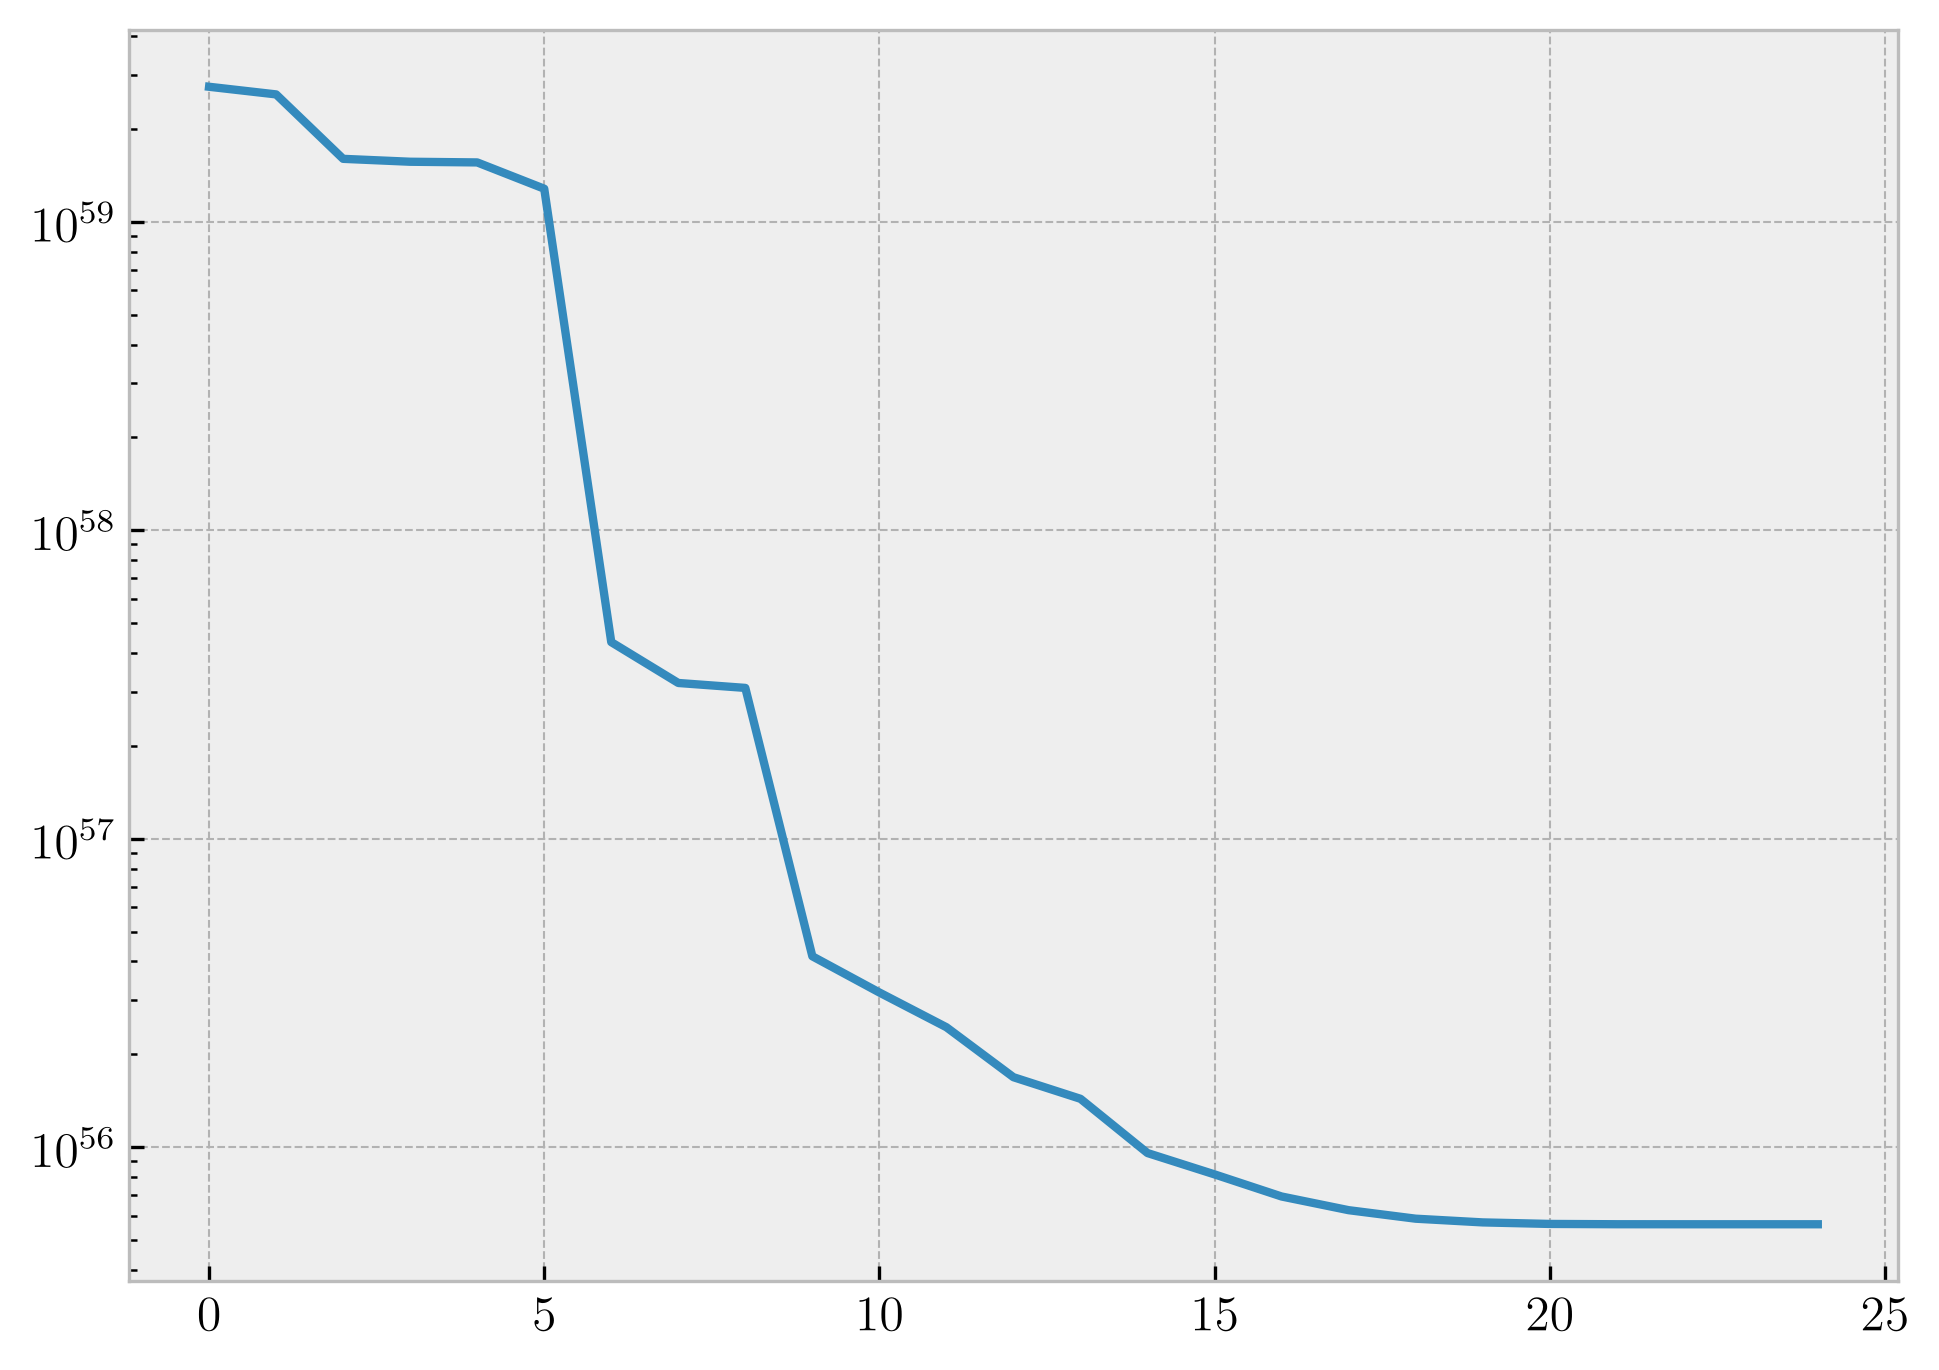

In [81]:
solved_losses = [info["history"][i]["loss"] for i in range(25)]
fig, ax  = plt.subplots()
ax.plot(np.arange(0, 25), solved_losses)
ax.set_yscale("log")


In [82]:
mask_3D = psf.random_bead_img_3D(grid = grid,
                                 z_levels = z_sample_levels,
                                 num_beads = 5,
                                 bead_size = 0.001)

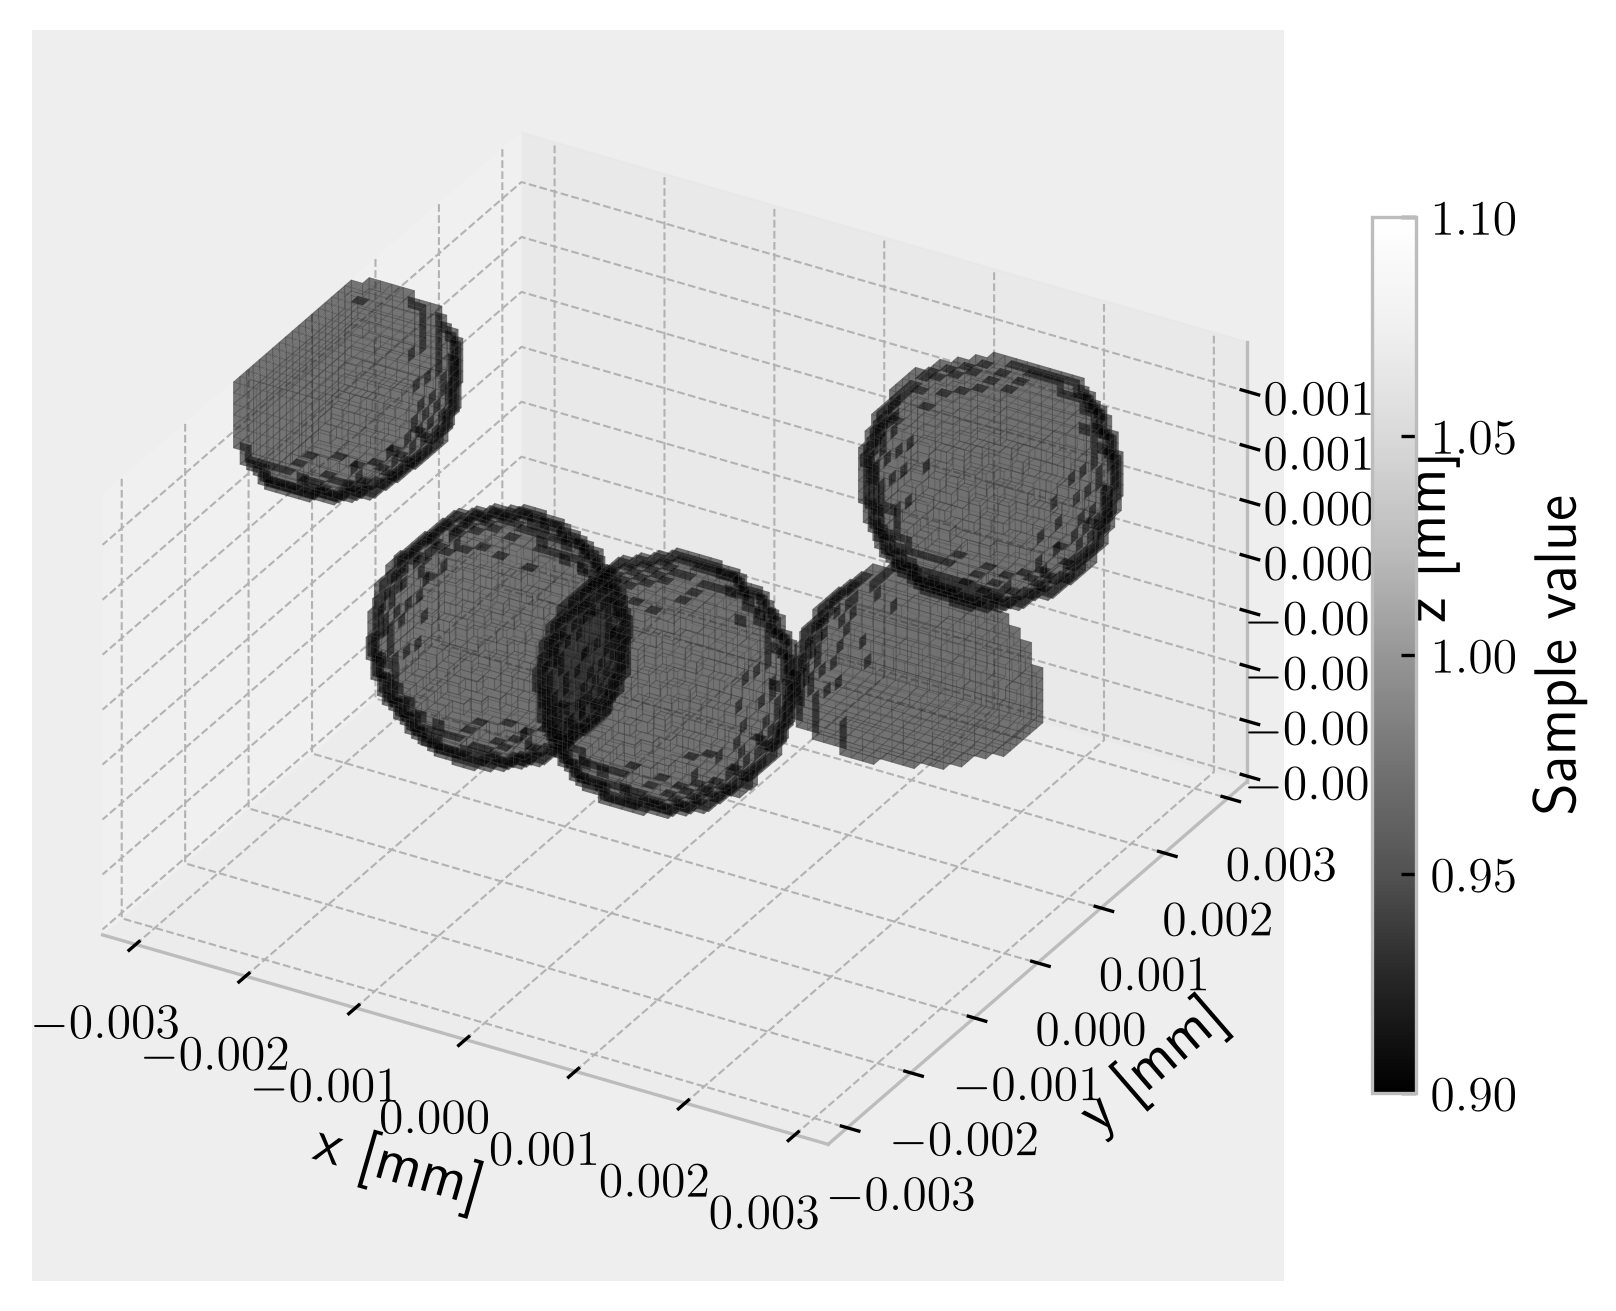

In [89]:
fig, ax = plotting.plot_sample_3D(mask_3D)

In [83]:
x, y, z, I = microscope.compute_image_3D(image = mask_3D,
                            aberration = aberration,
                            focal_z_levels = z_image_levels,
                            diversities = diversities)

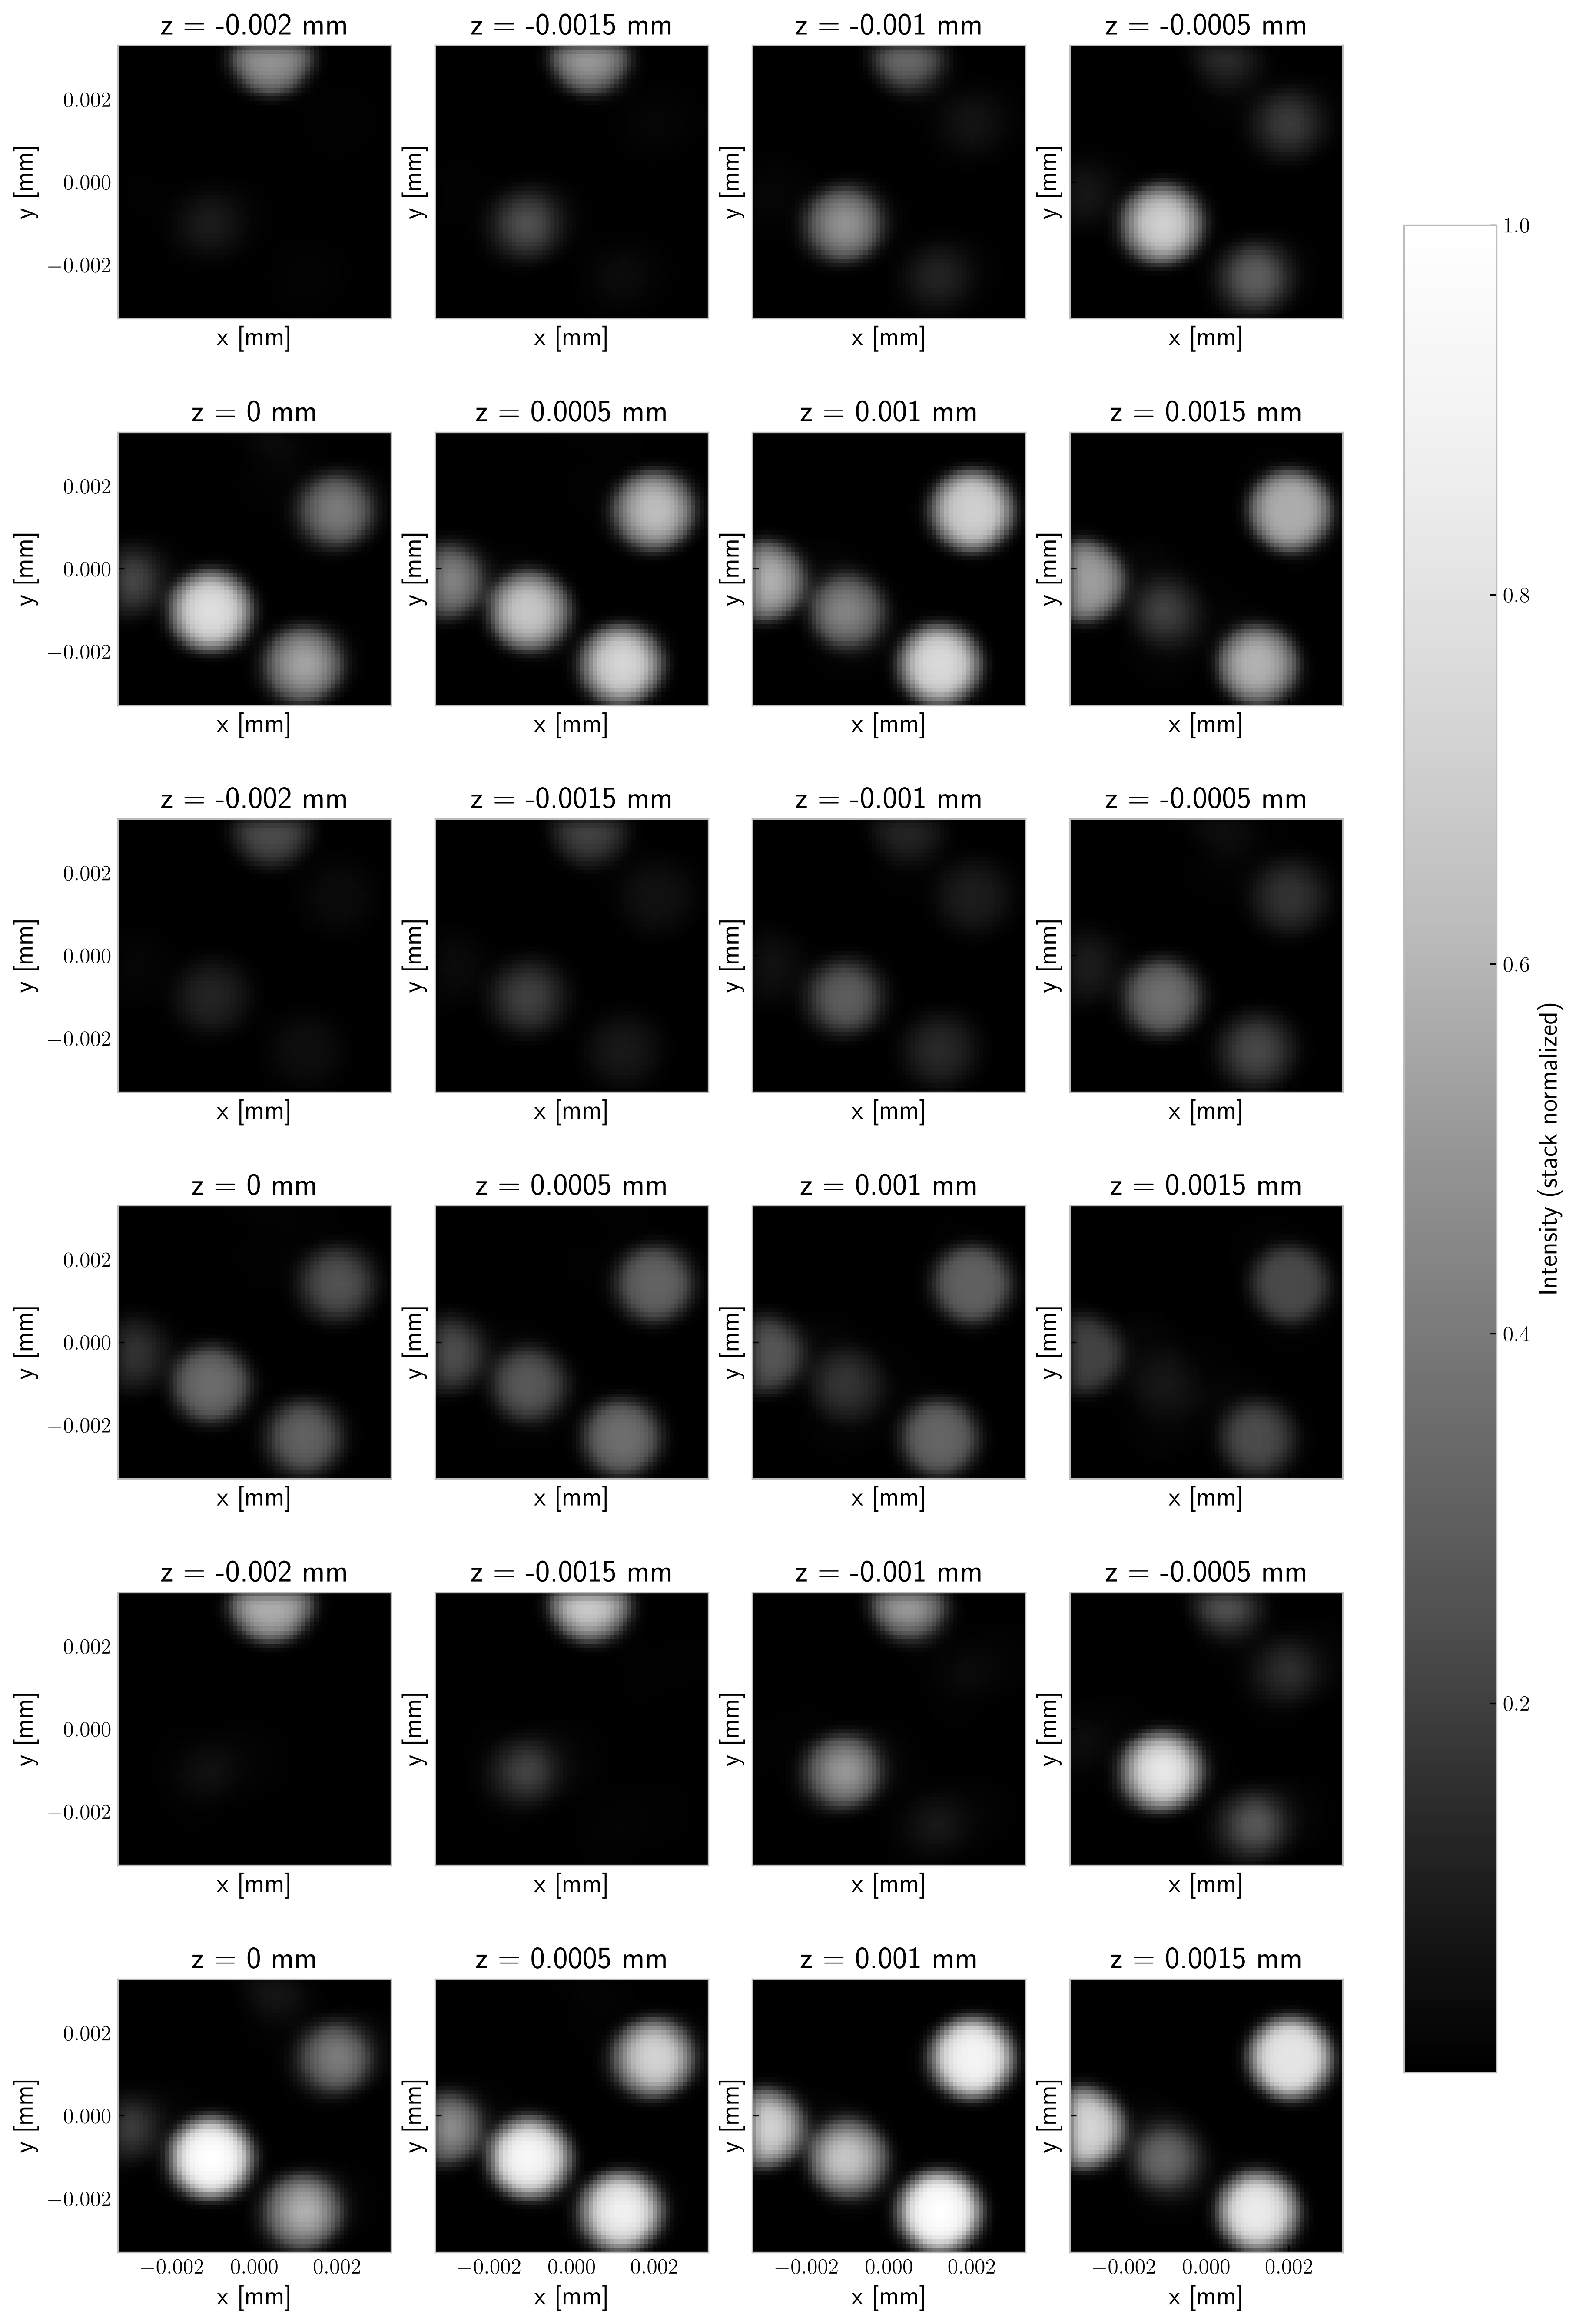

In [84]:
fig, axs = plotting.plot_image_stack(x, y, z, I, ncols=4)

In [85]:
estimated, info = reconstruction.optimize_aberration_3D(
    microscope=microscope,
    grid=grid,
    images=I,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    modes= modes,
    rho=1e48,
    diversities=diversities,
    initial_strengths=[0.0] * len(modes),
)

Iteration 0: loss=8.0777425022e+59, strengths (waves)=[0. 0. 0. 0. 0.]
Iteration 1: loss=7.9844409095e+59, strengths (waves)=[ 0.00083615  0.1        -0.00494117 -0.00175896  0.00114958]
Iteration 2: loss=5.7492520359e+59, strengths (waves)=[-0.00656089  0.          0.00302124  0.01394982 -0.00690904]
Iteration 3: loss=5.6275717693e+59, strengths (waves)=[ 0.0113343   0.05       -0.02015055 -0.0175997  -0.00651194]
Iteration 4: loss=5.4118645693e+59, strengths (waves)=[ 0.0093677   0.05909197  0.07984945 -0.02070518 -0.00763456]
Iteration 5: loss=3.7272821799e+58, strengths (waves)=[ 0.00482264  0.02852086 -0.02015055 -0.00903242 -0.05285185]
Iteration 6: loss=1.8340111270e+58, strengths (waves)=[ 0.01337886  0.07634807 -0.07015055 -0.03091811 -0.05492741]
Iteration 7: loss=9.1847182279e+57, strengths (waves)=[ 0.00950481  0.0848399  -0.05829383 -0.00698374 -0.04626526]
Iteration 8: loss=7.9914593030e+57, strengths (waves)=[ 0.0047386   0.07646271 -0.05945216 -0.00521056 -0.04770822]
I

In [86]:
from IPython.display import HTML, display

aberration_anim, object_anim = plotting.animate_reconstruction(
    info=info,
    modes=estimated.modes,
    microscope=microscope,
    grid=grid,
    images=I,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    rho=1e48,
    diversities=diversities,
    percentile=92,  # Fixed voxel threshold from the final object's percentile
    interval=500,   # Milliseconds per frame
    stride=1,       # Show every recorded iteration
)

In [88]:
aberration_anim.save("aberration.gif", writer="pillow", fps=4)
object_anim.save("object.gif", writer="pillow", fps=4)